# Análisis Predictivo de Ingresos de Freelancers en Upwork

## MIT Summer Program - Uruguay 2026

### Proyecto de Machine Learning

Este notebook presenta un análisis predictivo para estimar los ingresos potenciales de freelancers en la plataforma Upwork, utilizando datos reales del dataset de Kaggle.

**Autores:**  Abril Ocampo, Camilo Castellano, Gerardo Gonzalez

**Dataset:** [Upwork Dataset](https://www.kaggle.com/datasets) - ~60,000 registros de trabajos freelance de la plataforma Upwork

## Objetivo del Análisis

Desarrollar UN modelo predictivo:

### Modelo 1: Predicción de Ingresos (Regresión)
Estimar la **tarifa horaria promedio** (`Hourly_rate`) que puede cobrar un freelancer basándose en las principales características que se reflejan en el dataset:
- **Skills**
- **Search_Keyword**
- **EX_level_demand**
- **País del cliente**, etc.



### Modelos Recomendados

| Objetivo | Tipo | Modelos Recomendados |
|----------|------|---------------------|
| Predicción de Ingresos | Regresión | **Gradient Boosting**, Random Forest (R² ~0.18-0.20) |


### Metodología

1. **Carga y limpieza robusta** - Dataset de Upwork filtrado por trabajos "Hourly" y control de calidad de datos.
2. **Definición de Target** - Variable `Hourly_rate` calculada como el promedio entre `Start_rate` y `End_rate` (solo registros con ambos datos).
3. **Feature Engineering** - One-Hot Encoding de skills, países y keywords; eliminación de outliers (IQR).
4. **Entrenamiento** - Modelos de regresión optimizados con Grid Search implícito.

In [ ]:
# Google Colab mount - NOT NEEDED when running locally in VS Code
# The files are already accessible from your local Google Drive folder
from google.colab import drive
drive.mount('/content/drive')
#print("Running locally - no drive mount needed!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# PASO 0: Cargar librerías y Dataset de Upwork
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("CARGA DEL DATASET DE UPWORK FREELANCERS")
print("="*70)

# Cargar el dataset desde el archivo Excel
# excel_file = r"C:\Users\Usuario\My Drive (gerardo.gonzalez@estudiantes.utec.edu.uy)\MIT Summer\Week 0\Final_Upwork_Dataset.xlsx"
# print(f"\n📂 Cargando archivo: {excel_file}")
# df_raw = pd.read_excel(excel_file)

csv_file = r"/content/drive/MyDrive/Final_Upwork_Dataset.csv"

print(f"\n📂 Cargando archivo: {csv_file}")
df_raw = pd.read_csv(csv_file)

print(f"\n✅ Dataset cargado exitosamente!")
print(f"   📊 Filas originales: {df_raw.shape[0]:,}")
print(f"   📋 Columnas: {df_raw.shape[1]}")



CARGA DEL DATASET DE UPWORK FREELANCERS

📂 Cargando archivo: /content/drive/MyDrive/Final_Upwork_Dataset.csv

✅ Dataset cargado exitosamente!
   📊 Filas originales: 63,950
   📋 Columnas: 41


In [ ]:
df_raw.head()

,Job Title,Job_URL,EX_level_demand,Time_Limitation,Search_Keyword,Posted_from,Description,Category1_URL_search,Category_1,highlight,...,Client_Country,Connects_Num,New_Connects_Num,Rating,Feedback_Num,Payment_type,Job_Cost,Hourly_Rate,Start_rate,End_rate
0,Power bi specialist freelance,https://www.upwork.com/jobs/Power-specialist-f...,Expert,NaN,Data_science,5 minutes ago,Already data pooled and designed. Need to refi...,https://www.upwork.com/nx/jobs/search/?ontolog...,Data Analysis,data,...,United States,6.0,12.0,NaN,0.0,Fixed-price,"$2,500",NaN,0,NaN
1,Case Study (on-demand delivery startup),https://www.upwork.com/jobs/Case-Study-demand-...,Intermediate,NaN,Data_science,5 minutes ago,"Hi,\n\nWould you be able to help me do a case-...",https://www.upwork.com/nx/jobs/search/?ontolog...,Google Data Studio,Google Data Studio,...,Canada,4.0,8.0,5.000000,1.0,Fixed-price,$200,NaN,0,NaN
2,"File Maker Pro Reports, Charts, Query and Ongo...",https://www.upwork.com/jobs/File-Maker-Pro-Rep...,Intermediate,"3 to 6 months, Less than 30 hrs/week",Data_science,9 minutes ago,NITIAL PROJECT\n\nSet up Monthly Report mimick...,https://www.upwork.com/nx/jobs/search/?ontolog...,Report Writing,NaN,...,United States,6.0,12.0,5.000000,1.0,Hourly,NaN,$40.00,40,NaN
3,Implementation of EleutherAI/gpt-neox-20b,https://www.upwork.com/jobs/Implementation-Ele...,Expert,"3 to 6 months, Less than 30 hrs/week",Data_science,12 minutes ago,"As a first step, you will implement the instal...",https://www.upwork.com/nx/jobs/search/?ontolog...,Machine Learning Model,NaN,...,Canada,6.0,12.0,4.935536,26.0,Hourly,NaN,$35.00-$100.00,$35.00,$100.00
4,BI and Data Engineer for Upwork Finance System...,https://www.upwork.com/jobs/and-span-Data-span...,Expert,"More than 6 months, 30+ hrs/week",Data_science,14 minutes ago,The Upwork Finance Systems team is looking for...,https://www.upwork.com/nx/jobs/search/?ontolog...,Data Analysis,Data,...,United States,6.0,12.0,4.942242,12512.0,Hourly,NaN,NaN,0,NaN


In [ ]:
# ============================================================
# PASO 0.1: Análisis de valores faltantes (NA)
# ============================================================
print("\n" + "="*70)
print("ANÁLISIS DE VALORES FALTANTES (NA)")
print("="*70)

na_analysis = pd.DataFrame({
    'Columna': df_raw.columns,
    'NA_count': df_raw.isnull().sum().values,
    'NA_pct': (df_raw.isnull().sum() / len(df_raw) * 100).values
}).sort_values('NA_pct', ascending=False)

print("\n📊 Porcentaje de NA por columna:")
for _, row in na_analysis.iterrows():
    status = "✅" if row['NA_pct'] < 30 else "⚠️" if row['NA_pct'] < 50 else "❌"
    print(f"   {status} {row['Columna']}: {row['NA_pct']:.1f}% NA ({int(row['NA_count']):,} valores)")

# Filtrar columnas con menos del 50% de NA, PERO conservar End_rate y Hourly_Rate para la variable objetivo
MAX_NA_PCT = 50
cols_to_keep = na_analysis[na_analysis['NA_pct'] < MAX_NA_PCT]['Columna'].tolist()

# Asegurarse de incluir End_rate aunque tenga más de 50% NA (necesario para variable objetivo)
if 'End_rate' not in cols_to_keep and 'End_rate' in df_raw.columns:
    cols_to_keep.append('End_rate')
    print("\n⚠️ End_rate agregada manualmente (necesaria para variable objetivo)")

# Asegurarse de incluir Hourly_Rate aunque tenga más de 50% NA (necesario para variable objetivo)
if 'Hourly_Rate' not in cols_to_keep and 'Hourly_Rate' in df_raw.columns:
    cols_to_keep.append('Hourly_Rate')
    print("⚠️ Hourly_Rate agregada manualmente (necesaria para variable objetivo)")

cols_dropped = [col for col in df_raw.columns if col not in cols_to_keep]

print(f"\n🔧 Umbral de NA: {MAX_NA_PCT}%")
print(f"   ✅ Columnas conservadas: {len(cols_to_keep)}")
print(f"   ❌ Columnas eliminadas por exceso de NA: {len(cols_dropped)}")
if cols_dropped:
    print(f"      {cols_dropped}")

df = df_raw[cols_to_keep].copy()

# ============================================================
# PASO 0.2: Filtrar solo trabajos con pago por hora (HOURLY)
# ============================================================
print("\n" + "="*70)
print("FILTRO: SOLO TRABAJOS CON PAGO POR HORA")
print("="*70)

# Buscar columna de tipo de pago (puede ser Payment_Type o Payment_type)
payment_col = None
for col in df.columns:
    if 'payment' in col.lower() and 'type' in col.lower():
        payment_col = col
        break

if payment_col:
    print(f"\n📊 Columna encontrada: '{payment_col}'")
    print(f"Distribución de tipos de pago:")
    print(df[payment_col].value_counts())

    # Filtrar solo hourly
    df = df[df[payment_col].str.lower().str.contains('hourly', na=False)]
    print(f"\n✅ Filas después de filtrar por 'hourly': {len(df):,}")
else:
    print("⚠️ Columna de tipo de pago no encontrada")


ANÁLISIS DE VALORES FALTANTES (NA)

📊 Porcentaje de NA por columna:
   ❌ Enterprise_Client: 99.9% NA (63,897 valores)
   ❌ Category9_URL_search: 74.2% NA (47,469 valores)
   ❌ Category_9: 74.2% NA (47,469 valores)
   ❌ Job_Cost: 68.5% NA (43,837 valores)
   ❌ Category_8: 68.0% NA (43,514 valores)
   ❌ Category8_URL_search: 68.0% NA (43,514 valores)
   ❌ Time_Limitation: 64.0% NA (40,916 valores)
   ❌ Category7_URL_search: 60.6% NA (38,758 valores)
   ❌ Category_7: 60.6% NA (38,758 valores)
   ❌ End_rate: 59.4% NA (37,987 valores)
   ❌ Hourly_Rate: 58.5% NA (37,380 valores)
   ❌ Rating: 52.2% NA (33,357 valores)
   ❌ Category6_URL_search: 51.0% NA (32,643 valores)
   ❌ Category_6: 51.0% NA (32,643 valores)
   ⚠️ Category5_URL_search: 38.1% NA (24,372 valores)
   ⚠️ Category_5: 38.1% NA (24,372 valores)
   ✅ Category4_URL_search: 25.7% NA (16,407 valores)
   ✅ Category_4: 25.7% NA (16,407 valores)
   ✅ highlight: 21.6% NA (13,819 valores)
   ✅ Category3_URL_search: 14.0% NA (8,953 valor

In [ ]:
print("\n" + "="*70)
print("LIMPIEZA ADICIONAL: ELIMINAR COLUMNAS CON 'URL'")
print("="*70)

# Identificar y eliminar columnas que contienen 'URL' en su nombre
url_cols = [col for col in df.columns if 'URL' in col]

if url_cols:
    print(f"\n🗑️ Removiendo las siguientes columnas con 'URL' en su nombre: {url_cols}")
    df = df.drop(columns=url_cols)
    print(f"✅ Columnas con 'URL' eliminadas. El DataFrame ahora tiene {df.shape[1]} columnas.")
else:
    print("\nℹ️ No se encontraron columnas con 'URL' en su nombre para eliminar.")

print(f"\n📊 Dimensiones actuales del DataFrame: {df.shape[0]:,} filas, {df.shape[1]} columnas")


LIMPIEZA ADICIONAL: ELIMINAR COLUMNAS CON 'URL'

🗑️ Removiendo las siguientes columnas con 'URL' en su nombre: ['Category5_URL_search', 'Category4_URL_search', 'Category3_URL_search', 'Category2_URL_search', 'Category1_URL_search', 'Job_URL']
✅ Columnas con 'URL' eliminadas. El DataFrame ahora tiene 23 columnas.

📊 Dimensiones actuales del DataFrame: 40,333 filas, 23 columnas


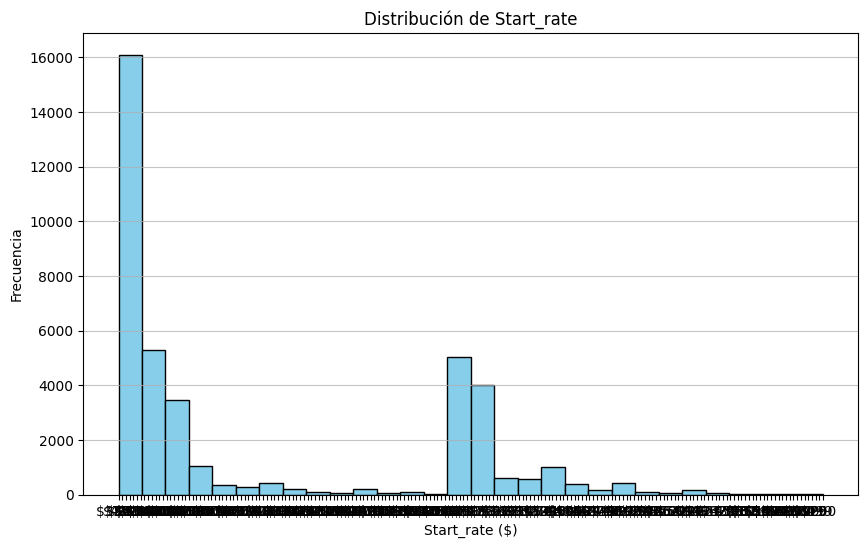

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Start_rate'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de Start_rate')
plt.xlabel('Start_rate ($)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# ============================================================
# PASO 0.3: Crear variable objetivo (Hourly_rate) a partir de la columna 'Hourly_Rate' (string)
# ============================================================
print("\n" + "="*70)
print("CREAR VARIABLE OBJETIVO: Hourly_rate (a partir de columna string)")
print("="*70)

# Función para parsear el string de Hourly_Rate
def parse_hourly_rate_string(rate_str):
    if pd.isna(rate_str) or rate_str == 'Not specified':
        return np.nan
    s = str(rate_str).replace('$', '').strip()
    if '-' in s:
        try:
            start, end = map(float, s.split('-'))
            return (start + end) / 2
        except ValueError:
            return np.nan
    else:
        try:
            return float(s)
        except ValueError:
            return np.nan

# Aplicar la función a la columna 'Hourly_Rate' para crear la nueva variable numérica
df['Hourly_rate_numeric'] = df['Hourly_Rate'].apply(parse_hourly_rate_string)

# Filtrar solo registros donde Hourly_rate_numeric es válido (> 0 y no NaN)
initial_rows = len(df)
df = df[df['Hourly_rate_numeric'].notna() & (df['Hourly_rate_numeric'] > 0)].copy()
print(f"\n✅ Registros con Hourly_rate_numeric válido: {len(df):,}")
print(f"   Filas restantes después de filtrar: {len(df):,} (se eliminaron {initial_rows - len(df):,} filas)")

# Renombrar para usar como variable objetivo principal
df['Hourly_rate'] = df['Hourly_rate_numeric']

print(f"\n📈 Estadísticas de la nueva variable objetivo (Hourly_rate):")
print(f"   Min: ${df['Hourly_rate'].min():.2f}")
print(f"   Max: ${df['Hourly_rate'].max():.2f}")
print(f"   Media: ${df['Hourly_rate'].mean():.2f}")
print(f"   Mediana: ${df['Hourly_rate'].median():.2f}")




CREAR VARIABLE OBJETIVO: Hourly_rate (a partir de columna string)

✅ Registros con Hourly_rate_numeric válido: 26,570
   Filas restantes después de filtrar: 26,570 (se eliminaron 13,763 filas)

📈 Estadísticas de la nueva variable objetivo (Hourly_rate):
   Min: $3.00
   Max: $999.00
   Media: $30.56
   Mediana: $24.00


In [ ]:
# ============================================================
# PASO 0.4: Eliminar outliers en Hourly_rate
# ============================================================
print("\n" + "="*70)
print("LIMPIEZA: ELIMINACIÓN DE OUTLIERS EN HOURLY_RATE")
print("="*70)

# Eliminar outliers usando IQR (método de cuartiles)
Q1 = df['Hourly_rate'].quantile(0.25)
Q3 = df['Hourly_rate'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = max(0, Q1 - 1.5 * IQR) # Aseguramos que el límite inferior no sea negativo
upper_bound = Q3 + 1.5 * IQR

outliers_count = len(df[(df['Hourly_rate'] < lower_bound) | (df['Hourly_rate'] > upper_bound)])
df = df[(df['Hourly_rate'] >= lower_bound) & (df['Hourly_rate'] <= upper_bound)]

print(f"\n🔧 Eliminación de outliers (método IQR):")
print(f"   Q1: ${Q1:.2f}, Q3: ${Q3:.2f}, IQR: ${IQR:.2f}")
print(f"   Rango aceptado: ${lower_bound:.2f} - ${upper_bound:.2f}")
print(f"   ❌ Outliers eliminados: {outliers_count:,}")

print(f"\n📈 Estadísticas de Hourly_rate DESPUÉS de eliminar outliers:")
print(f"   Min: ${df['Hourly_rate'].min():.2f}")
print(f"   Max: ${df['Hourly_rate'].max():.2f}")
print(f"   Media: ${df['Hourly_rate'].mean():.2f}")
print(f"   Mediana: ${df['Hourly_rate'].median():.2f}")


LIMPIEZA: ELIMINACIÓN DE OUTLIERS EN HOURLY_RATE

🔧 Eliminación de outliers (método IQR):
   Q1: $15.00, Q3: $37.50, IQR: $22.50
   Rango aceptado: $0.00 - $71.25
   ❌ Outliers eliminados: 1,454

📈 Estadísticas de Hourly_rate DESPUÉS de eliminar outliers:
   Min: $3.00
   Max: $71.00
   Media: $26.06
   Mediana: $22.50


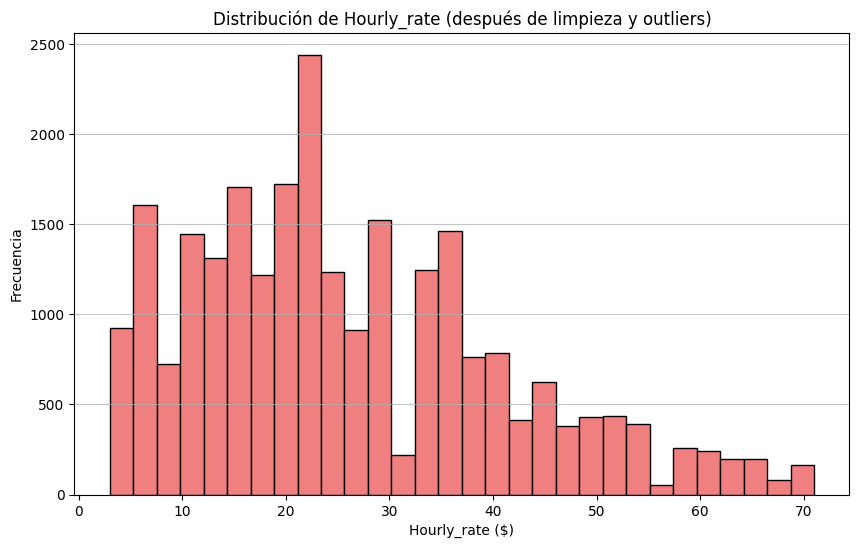

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Hourly_rate'], bins=30, color='lightcoral', edgecolor='black')
plt.title('Distribución de Hourly_rate (después de limpieza y outliers)')
plt.xlabel('Hourly_rate ($)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# ============================================================
# RESUMEN FINAL DEL DATASET LIMPIO
# ============================================================
print("\n" + "="*70)
print("🎯 RESUMEN DEL DATASET LIMPIO (PARA ENTRENAR MODELOS)")
print("="*70)
print(f"\n✅ Dataset final listo para modelar:")
print(f"   📊 Filas: {df.shape[0]:,}")
print(f"   📋 Columnas: {df.shape[1]}")
print(f"\n🎯 Variable objetivo: Hourly_rate")

print(f"\n📋 Columnas del dataset limpio:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2}. {col}")

print(f"\n📊 Primeras 5 filas:")
display(df.head())


🎯 RESUMEN DEL DATASET LIMPIO (PARA ENTRENAR MODELOS)

✅ Dataset final listo para modelar:
   📊 Filas: 25,116
   📋 Columnas: 25

🎯 Variable objetivo: Hourly_rate

📋 Columnas del dataset limpio:
    1. Category_5
    2. Category_4
    3. highlight
    4. Category_3
    5. EX_level_demand
    6. Category_2
    7. Spent($)
    8. Category_1
    9. Client_Country
   10. Posted_from
   11. Description
   12. Job Title
   13. Search_Keyword
   14. Payment_type
   15. Connects_Num
   16. Applicants_Num
   17. Payment_Situation
   18. New_Connects_Num
   19. Feedback_Num
   20. Start_rate
   21. Freelancers_Num
   22. End_rate
   23. Hourly_Rate
   24. Hourly_rate_numeric
   25. Hourly_rate

📊 Primeras 5 filas:


,Category_5,Category_4,highlight,Category_3,EX_level_demand,Category_2,Spent($),Category_1,Client_Country,Posted_from,...,Applicants_Num,Payment_Situation,New_Connects_Num,Feedback_Num,Start_rate,Freelancers_Num,End_rate,Hourly_Rate,Hourly_rate_numeric,Hourly_rate
2,NaN,NaN,NaN,NaN,Intermediate,Custom Graphics,200.0,Report Writing,United States,9 minutes ago,...,Less than 5,Payment verified,12.0,1.0,40,1,NaN,$40.00,40.0,40.0
3,NaN,NaN,NaN,Python,Expert,Machine Learning,200000.0,Machine Learning Model,Canada,12 minutes ago,...,Less than 5,Payment verified,12.0,26.0,$35.00,1,$100.00,$35.00-$100.00,67.5,67.5
8,Microsoft Visual Studio,Azure DevOps,Data,ETL,Intermediate,Microsoft Azure,0.0,SQL,Poland,22 minutes ago,...,Less than 5,Payment verified,12.0,0.0,$25.00,1,$35.00,$25.00-$35.00,30.0,30.0
10,NaN,NaN,Data Extraction,NaN,Intermediate,ETL,0.0,Data Extraction,Bolivia,33 minutes ago,...,Less than 5,Payment unverified,4.0,0.0,$8.00,1,$25.00,$8.00-$25.00,16.5,16.5
12,NaN,Market Research,data,Statistics,Intermediate,SurveyMonkey,10000.0,Data Analysis,United States,37 minutes ago,...,Less than 5,Payment verified,4.0,185.0,$45.00,1,$73.00,$45.00-$73.00,59.0,59.0


In [ ]:
category_cols_up_to_3 = [f'Category_{i}' for i in range(1, 4) if f'Category_{i}' in df.columns]

if category_cols_up_to_3:
    # Count rows where ALL of the specified category columns are not null
    num_observations = df[category_cols_up_to_3].notna().all(axis=1).sum()
    print(f"Número de observaciones con valores EN TODAS las columnas hasta Category 3 (sin NaN): {num_observations:,}")
else:
    print("No se encontraron columnas de categoría (Category_1 a Category_3) en el DataFrame.")

Número de observaciones con valores EN TODAS las columnas hasta Category 3 (sin NaN): 21,439


In [ ]:
print("\n" + "="*70)
print("LIMPIEZA ADICIONAL: CONSERVAR SOLO CATEGORY_1 A CATEGORY_3")
print("="*70)

cols_to_drop_for_categories = [f'Category_{i}' for i in range(4, 6) if f'Category_{i}' in df.columns]

if cols_to_drop_for_categories:
    print(f"\n🗑️ Removiendo las siguientes columnas de categoría: {cols_to_drop_for_categories}")
    df = df.drop(columns=cols_to_drop_for_categories)
    print(f"✅ Columnas eliminadas. El DataFrame ahora tiene {df.shape[1]} columnas.")
else:
    print("\nℹ️ No se encontraron columnas de categoría (Category_4 o Category_5) para eliminar.")

print(f"\n📊 Dimensiones actuales del DataFrame: {df.shape[0]:,} filas, {df.shape[1]} columnas")


LIMPIEZA ADICIONAL: CONSERVAR SOLO CATEGORY_1 A CATEGORY_3

🗑️ Removiendo las siguientes columnas de categoría: ['Category_4', 'Category_5']
✅ Columnas eliminadas. El DataFrame ahora tiene 23 columnas.

📊 Dimensiones actuales del DataFrame: 25,116 filas, 23 columnas


# Data exploration and Preprocessing

ANÁLISIS DE DATOS PARA PREDICCIÓN DE INGRESOS

🎯 Variable objetivo (ingresos): Hourly_rate
🔧 Variable de categoría/keyword: Search_Keyword

ESTADÍSTICAS DESCRIPTIVAS DE TARIFA POR HORA

📈 Estadísticas de Hourly_rate:
count    25116.000000
mean        26.059902
std         15.011639
min          3.000000
25%         15.000000
50%         22.500000
75%         35.000000
max         71.000000
Name: Hourly_rate, dtype: float64


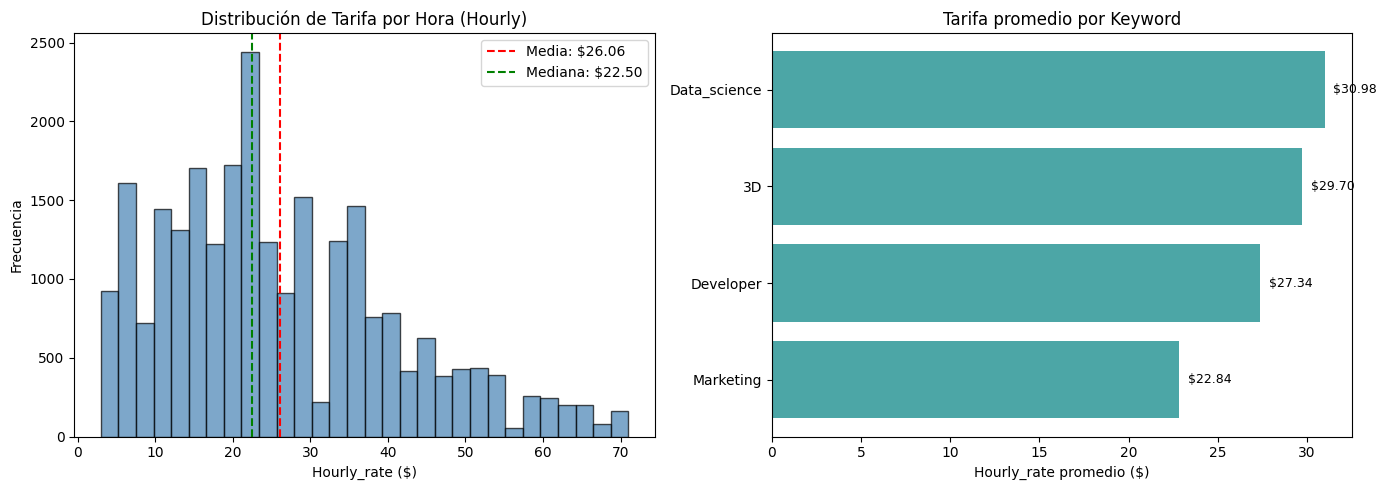


TARIFA PROMEDIO POR NIVEL DE EXPERIENCIA
                 Media ($)  Mediana ($)      N
EX_level_demand                               
Entry level          19.83         16.5   2222
Expert               30.10         30.0   8422
Intermediate         24.04         22.5  11706

CORRELACIONES CON TARIFA POR HORA

📊 Correlaciones con Hourly_rate:
   Hourly_rate_numeric: 1.0000
   Spent($): 0.0168
   Freelancers_Num: -0.0174
   Feedback_Num: -0.0326
   Connects_Num: -0.0788
   New_Connects_Num: -0.0788


In [ ]:
# ============================================================
# PASO 1: Exploración de datos para el modelo predictivo
# ============================================================

print("="*70)
print("ANÁLISIS DE DATOS PARA PREDICCIÓN DE INGRESOS")
print("="*70)

# Identificar columnas relevantes
# Usar 'Hourly_rate' que ya fue procesada y es numérica
income_col = 'Hourly_rate'
skills_col = 'Search_Keyword' if 'Search_Keyword' in df.columns else None

print(f"\n🎯 Variable objetivo (ingresos): {income_col}")
print(f"🔧 Variable de categoría/keyword: {skills_col}")

# Asegurarse de que income_col sea numérica (ya debería serlo después del PASO 0.3 y 0.4)
df[income_col] = pd.to_numeric(df[income_col], errors='coerce')

# Estadísticas descriptivas
print("\n" + "="*70)
print("ESTADÍSTICAS DESCRIPTIVAS DE TARIFA POR HORA")
print("="*70)

print(f"\n📈 Estadísticas de {income_col}:")
print(df[income_col].describe())

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de tarifas
axes[0].hist(df[income_col].values, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel(f'{income_col} ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title(f'Distribución de Tarifa por Hora (Hourly)')
axes[0].axvline(df[income_col].mean(), color='red', linestyle='--', label=f'Media: ${df[income_col].mean():.2f}')
axes[0].axvline(df[income_col].median(), color='green', linestyle='--', label=f'Mediana: ${df[income_col].median():.2f}')
axes[0].legend()

# Por Search_Keyword
if skills_col and skills_col in df.columns:
    # Asegurarse de que Search_Keyword no tenga NaNs antes de agrupar
    keyword_avg = df.dropna(subset=[skills_col]).groupby(skills_col)[income_col].mean().sort_values(ascending=True)
    # Limitar a las top N keywords para visualización si hay muchas
    if len(keyword_avg) > 10:
        keyword_avg = keyword_avg.tail(10) # Mostrar las 10 keywords con tarifas más altas

    bars = axes[1].barh(keyword_avg.index, keyword_avg.values, color='teal', alpha=0.7)
    axes[1].set_xlabel(f'{income_col} promedio ($)')
    axes[1].set_title('Tarifa promedio por Keyword')
    for i, (kw, val) in enumerate(zip(keyword_avg.index, keyword_avg.values)):
        axes[1].text(val + 0.5, i, f'${val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Análisis por nivel de experiencia
if 'EX_level_demand' in df.columns:
    print("\n" + "="*70)
    print("TARIFA PROMEDIO POR NIVEL DE EXPERIENCIA")
    print("="*70)
    # Asegurarse de que EX_level_demand no tenga NaNs antes de agrupar
    exp_stats = df.dropna(subset=['EX_level_demand']).groupby('EX_level_demand')[income_col].agg(['mean', 'median', 'count'])
    exp_stats.columns = ['Media ($)', 'Mediana ($)', 'N']
    print(exp_stats.round(2))

# Correlaciones numéricas
print("\n" + "="*70)
print("CORRELACIONES CON TARIFA POR HORA")
print("="*70)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if income_col in numeric_cols:
    correlations = df[numeric_cols].corr()[income_col].drop(income_col).sort_values(ascending=False)
    print(f"\n📊 Correlaciones con {income_col}:")
    for col, corr in correlations.items():
        if abs(corr) > 0.01:  # Solo mostrar correlaciones relevantes
            print(f"   {col}: {corr:.4f}")

## 📖 The Story of Our Problem: Freelancer Challenges and Our Solution (ABT)

### **A: Action**

Our goal is to build a predictive model that helps freelancers navigate the competitive Upwork landscape by estimating their potential hourly rates and quantifying job opportunities. This proactive approach aims to empower them to make informed decisions and enhance their job search effectiveness.

### **B: Background**

In today's globalized economy, the freelance market is booming, with countless talented individuals seeking work on platforms like Upwork. However, this growth has led to significant challenges: freelancers often struggle with setting appropriate rates, understanding the true demand for their skills, and assessing the competitiveness of various job postings. They frequently face the daunting task of sifting through thousands of jobs, unsure of which opportunities offer the best combination of fair compensation and a high chance of success. This lack of clear, data-driven guidance leads to underpricing, wasted effort on highly competitive bids, and a general sense of uncertainty in their professional trajectory.

### **T: Thesis**

**Therefore, we hypothesize that by developing a dual predictive model—one for hourly rate estimation and another for an 'opportunity score'—we can provide freelancers with the crucial insights needed to overcome these obstacles.** This model will leverage historical job data to not only suggest competitive hourly rates based on skills and experience but also to calculate a unique opportunity score. This score will account for factors like applicant volume, client verification, and job connection costs, offering a holistic view of a job's potential success. Our work aims to transform the freelance job search from a guessing game into a strategic, data-informed process, ultimately improving job satisfaction and earning potential for freelancers worldwide.

### ✨ Enfoque de Alto Nivel

Nuestra solución se basa en dos modelos predictivos principales:

#### **1. Modelo de Predicción de Ingresos**
*   **Tarea ML:** Regresión
*   **Objetivo (Output):** Predecir la **Tarifa Horaria Promedio** (`Hourly_rate`)
*   **Entradas (Inputs):**
    *   **Skills:** (e.g., 'Python', 'Data Analysis', 'Machine Learning')
    *   **Keyword de Búsqueda:** (e.g., 'Data science', 'Developer', 'Marketing')
    *   **Nivel de Experiencia:** (e.g., 'Entry Level', 'Intermediate', 'Expert')
    *   **Factores del Cliente:** País del cliente, Verificación de pago., etc.


# Prediction models

# Data Visualization


VISUALIZATION OF THE TARGET VARIABLE: HOURLY_RATE


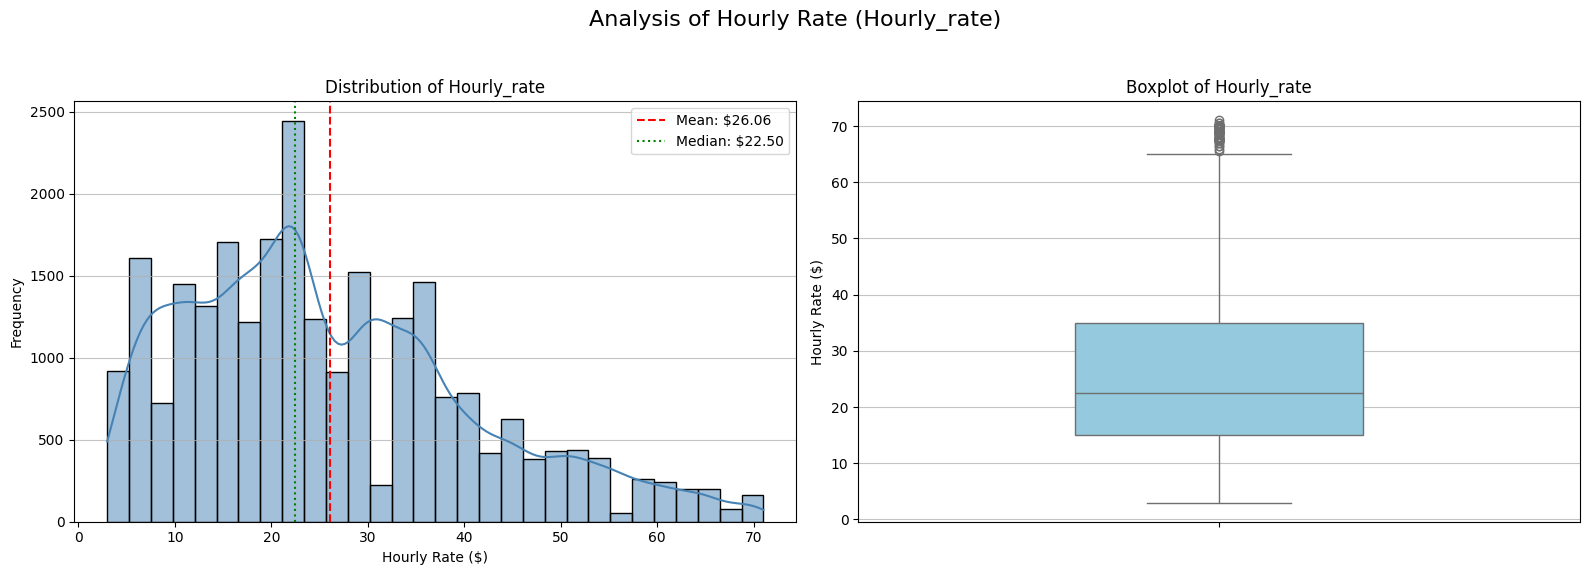


INITIAL CONCLUSIONS ON HOURLY_RATE

📈 The average hourly rate is $26.06.
   The median is $22.50, indicating a slightly skewed distribution.
   The range of rates is mostly between $15.00 and $35.00.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*70)
print("VISUALIZATION OF THE TARGET VARIABLE: HOURLY_RATE")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analysis of Hourly Rate (Hourly_rate)', fontsize=16)

# Histograma de Hourly_rate
sns.histplot(df['Hourly_rate'], bins=30, kde=True, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Hourly_rate')
axes[0].set_xlabel('Hourly Rate ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Hourly_rate'].mean(), color='red', linestyle='--', label=f'Mean: ${df['Hourly_rate'].mean():.2f}')
axes[0].axvline(df['Hourly_rate'].median(), color='green', linestyle=':', label=f'Median: ${df['Hourly_rate'].median():.2f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.75)

# Boxplot de Hourly_rate
sns.boxplot(y=df['Hourly_rate'], ax=axes[1], color='skyblue', width=0.4)
axes[1].set_title('Boxplot of Hourly_rate')
axes[1].set_ylabel('Hourly Rate ($)')
axes[1].grid(axis='y', alpha=0.75)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n" + "="*70)
print("INITIAL CONCLUSIONS ON HOURLY_RATE")
print("="*70)
print(f"\n📈 The average hourly rate is ${df['Hourly_rate'].mean():.2f}.")
print(f"   The median is ${df['Hourly_rate'].median():.2f}, indicating a slightly skewed distribution.")
print(f"   The range of rates is mostly between ${df['Hourly_rate'].quantile(0.25):.2f} and ${df['Hourly_rate'].quantile(0.75):.2f}.")


In [ ]:
# ============================================================
# PASO 2: Preparación de datos para modelos de regresión lineal
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("="*70)
print("PREPARACIÓN DE DATOS PARA MODELOS DE REGRESIÓN")
print("="*70)

df_model = df.copy()


PREPARACIÓN DE DATOS PARA MODELOS DE REGRESIÓN


In [ ]:
# ============================================================
# PASO 2.1: Variable objetivo - TARIFA POR HORA
# ============================================================
print("\n🎯 Variable objetivo: Hourly_rate")

target_col = 'Hourly_rate'
print(f"   Variable objetivo: {target_col}")
print(f"   Rango: ${df_model[target_col].min():.2f} - ${df_model[target_col].max():.2f}")
print(f"   Media: ${df_model[target_col].mean():.2f}")
print(f"   Mediana: ${df_model[target_col].median():.2f}")
print(f"   Desv. Est.: ${df_model[target_col].std():.2f}")



🎯 Variable objetivo: Hourly_rate
   Variable objetivo: Hourly_rate
   Rango: $3.00 - $71.00
   Media: $26.06
   Mediana: $22.50
   Desv. Est.: $15.01


In [ ]:
# ============================================================
# PASO 2.2: Codificar variables categóricas
# ============================================================
print("\n" + "="*70)
print("🏷️ CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("="*70)

# Codificar Search_Keyword con One-Hot Encoding
keyword_cols = []
if 'Search_Keyword' in df_model.columns:
    keyword_dummies = pd.get_dummies(df_model['Search_Keyword'], prefix='keyword')
    keyword_cols = keyword_dummies.columns.tolist()
    df_model = pd.concat([df_model, keyword_dummies], axis=1)
    print(f"✅ Search_Keyword: {len(keyword_cols)} categorías (One-Hot)")

# Codificar nivel de experiencia con One-Hot Encoding
exp_cols = []
if 'EX_level_demand' in df_model.columns:
    exp_dummies = pd.get_dummies(df_model['EX_level_demand'], prefix='exp')
    exp_cols = exp_dummies.columns.tolist()
    df_model = pd.concat([df_model, exp_dummies], axis=1)
    print(f"✅ EX_level_demand: {len(exp_cols)} categorías (One-Hot)")

# Codificar Client_Country (Top 15 países + Other para más granularidad)
country_cols = []
if 'Client_Country' in df_model.columns:
    top_countries = df_model['Client_Country'].value_counts().head(15).index.tolist()
    df_model['country_grouped'] = df_model['Client_Country'].apply(
        lambda x: x if x in top_countries else 'Other'
    )
    country_dummies = pd.get_dummies(df_model['country_grouped'], prefix='country')
    country_cols = country_dummies.columns.tolist()
    df_model = pd.concat([df_model, country_dummies], axis=1)
    print(f"✅ Client_Country: {len(country_cols)} categorías (Top 15 + Other)")

# Codificar Payment_Situation
if 'Payment_Situation' in df_model.columns:
    df_model['payment_verified'] = df_model['Payment_Situation'].apply(
        lambda x: 1 if 'verified' in str(x).lower() else 0
    )
    print(f"✅ Payment_Situation: variable binaria 'payment_verified'")

# ============================================================
# PASO 2.3: Preparar SKILLS (Category_1 a Category_5)
# ============================================================
print("\n" + "="*70)
print("🔧 PREPARANDO FEATURES: SKILLS")
print("="*70)

category_cols = [f'Category_{i}' for i in range(1, 6) if f'Category_{i}' in df_model.columns]
print(f"Columnas de skills encontradas: {len(category_cols)}")

# Extraer skills
def extract_skills(row):
    skills = []
    for col in category_cols:
        if pd.notna(row[col]) and str(row[col]).strip() not in ['', 'nan']:
            skills.append(str(row[col]).strip())
    return skills

df_model['skills_list'] = df_model.apply(extract_skills, axis=1)
df_model['num_skills'] = df_model['skills_list'].apply(len)

# Contar frecuencia de skills
skill_counts = {}
for skills in df_model['skills_list']:
    for skill in skills:
        skill_counts[skill] = skill_counts.get(skill, 0) + 1

top_skills = sorted(skill_counts.items(), key=lambda x: x[1], reverse=True)
print(f"Total de skills únicos: {len(skill_counts)}")
print(f"\n🏆 Top 10 Skills más demandados:")
for skill, count in top_skills[:10]:
    print(f"   - {skill}: {count:,} trabajos")

# Crear dummies para top skills (aumentado a 30)
skill_dummy_cols = []
top_n_skills = [s[0] for s in top_skills[:30]]  # Top 30 skills
for skill in top_n_skills:
    col_name = f'skill_{skill.replace(" ", "_").replace("/", "_").replace("-", "_")}'
    df_model[col_name] = df_model['skills_list'].apply(lambda x: 1 if skill in x else 0)
    skill_dummy_cols.append(col_name)

print(f"\n✅ Variables dummy de skills creadas: {len(skill_dummy_cols)}")

# ============================================================
# PASO 2.4: Convertir y crear variables numéricas
# ============================================================
print("\n" + "="*70)
print("🔢 PREPARANDO VARIABLES NUMÉRICAS")
print("="*70)

numeric_feature_cols = ['num_skills']

# Convertir columnas numéricas existentes
for col in ['Applicants_Num', 'Connects_Num', 'Feedback_Num', 'Freelancers_Num', 'Spent($)']:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce').fillna(0)
        numeric_feature_cols.append(col)
        print(f"✅ {col}: convertido a numérico")

# Crear features adicionales para mejorar el modelo
print("\n🔧 Creando features adicionales...")

# Log de Spent (el gasto del cliente puede indicar presupuesto)
if 'Spent($)' in df_model.columns:
    df_model['log_spent'] = np.log1p(df_model['Spent($)'])
    numeric_feature_cols.append('log_spent')
    print("✅ log_spent: log del gasto del cliente")

# Ratio de competencia (menos aplicantes = menos competencia)
if 'Applicants_Num' in df_model.columns:
    # Convertir a numérico si tiene texto como "Less than 5"
    df_model['applicants_numeric'] = df_model['Applicants_Num'].apply(
        lambda x: 2.5 if 'less' in str(x).lower() else (
            float(str(x).replace('+', '').split('-')[0]) if str(x).replace('+', '').replace('-', '').replace(' ', '').isdigit()
            else 5
        )
    )
    numeric_feature_cols.append('applicants_numeric')
    print("✅ applicants_numeric: número de aplicantes normalizado")

# ============================================================
# PASO 2.5: Definir features finales
# ============================================================
print("\n" + "="*70)
print("📋 SELECCIÓN DE FEATURES PARA EL MODELO")
print("="*70)

# Recopilar todas las columnas de features
feature_cols = []

# Variables numéricas
feature_cols.extend(numeric_feature_cols)

# Variables dummy de keywords
feature_cols.extend(keyword_cols)

# Variables dummy de experiencia
feature_cols.extend(exp_cols)

# Variables dummy de país
feature_cols.extend(country_cols)

# Variables dummy de skills
feature_cols.extend(skill_dummy_cols)

# Payment verified
if 'payment_verified' in df_model.columns:
    feature_cols.append('payment_verified')

# Filtrar solo columnas que existen
feature_cols = [c for c in feature_cols if c in df_model.columns]

print(f"\n📊 Total de features: {len(feature_cols)}")
print(f"   - Numéricas: {len(numeric_feature_cols)}")
print(f"   - Keywords (One-Hot): {len(keyword_cols)}")
print(f"   - Experiencia (One-Hot): {len(exp_cols)}")
print(f"   - País (One-Hot): {len(country_cols)}")
print(f"   - Skills (One-Hot): {len(skill_dummy_cols)}")

# Preparar X e y - asegurar que solo sean valores numéricos
X = df_model[feature_cols].fillna(0).astype(float)
y = df_model[target_col].astype(float)

# Verificar que no hay valores no numéricos
print(f"\n🔍 Verificando tipos de datos:")
print(f"   X dtypes: {X.dtypes.unique()}")
print(f"   Hay NaN en X: {X.isnull().any().any()}")

print(f"\n✅ Datos preparados:")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")

# Guardar variable objetivo para referencia
target_income = target_col


🏷️ CODIFICACIÓN DE VARIABLES CATEGÓRICAS
✅ Search_Keyword: 4 categorías (One-Hot)
✅ EX_level_demand: 3 categorías (One-Hot)
✅ Client_Country: 16 categorías (Top 15 + Other)
✅ Payment_Situation: variable binaria 'payment_verified'

🔧 PREPARANDO FEATURES: SKILLS
Columnas de skills encontradas: 3
Total de skills únicos: 2757

🏆 Top 10 Skills más demandados:
   - Web Development: 3,799 trabajos
   - Social Media Marketing: 2,891 trabajos
   - WordPress: 1,637 trabajos
   - Marketing Strategy: 1,567 trabajos
   - JavaScript: 1,398 trabajos
   - Web Design: 1,252 trabajos
   - Python: 1,025 trabajos
   - Lead Generation: 922 trabajos
   - PHP: 790 trabajos
   - Shopify: 777 trabajos

✅ Variables dummy de skills creadas: 30

🔢 PREPARANDO VARIABLES NUMÉRICAS
✅ Applicants_Num: convertido a numérico
✅ Connects_Num: convertido a numérico
✅ Feedback_Num: convertido a numérico
✅ Freelancers_Num: convertido a numérico
✅ Spent($): convertido a numérico

🔧 Creando features adicionales...
✅ log_spent:


AVERAGE HOURLY RATE FOR TOP 30 SKILLS (BAR PLOT)


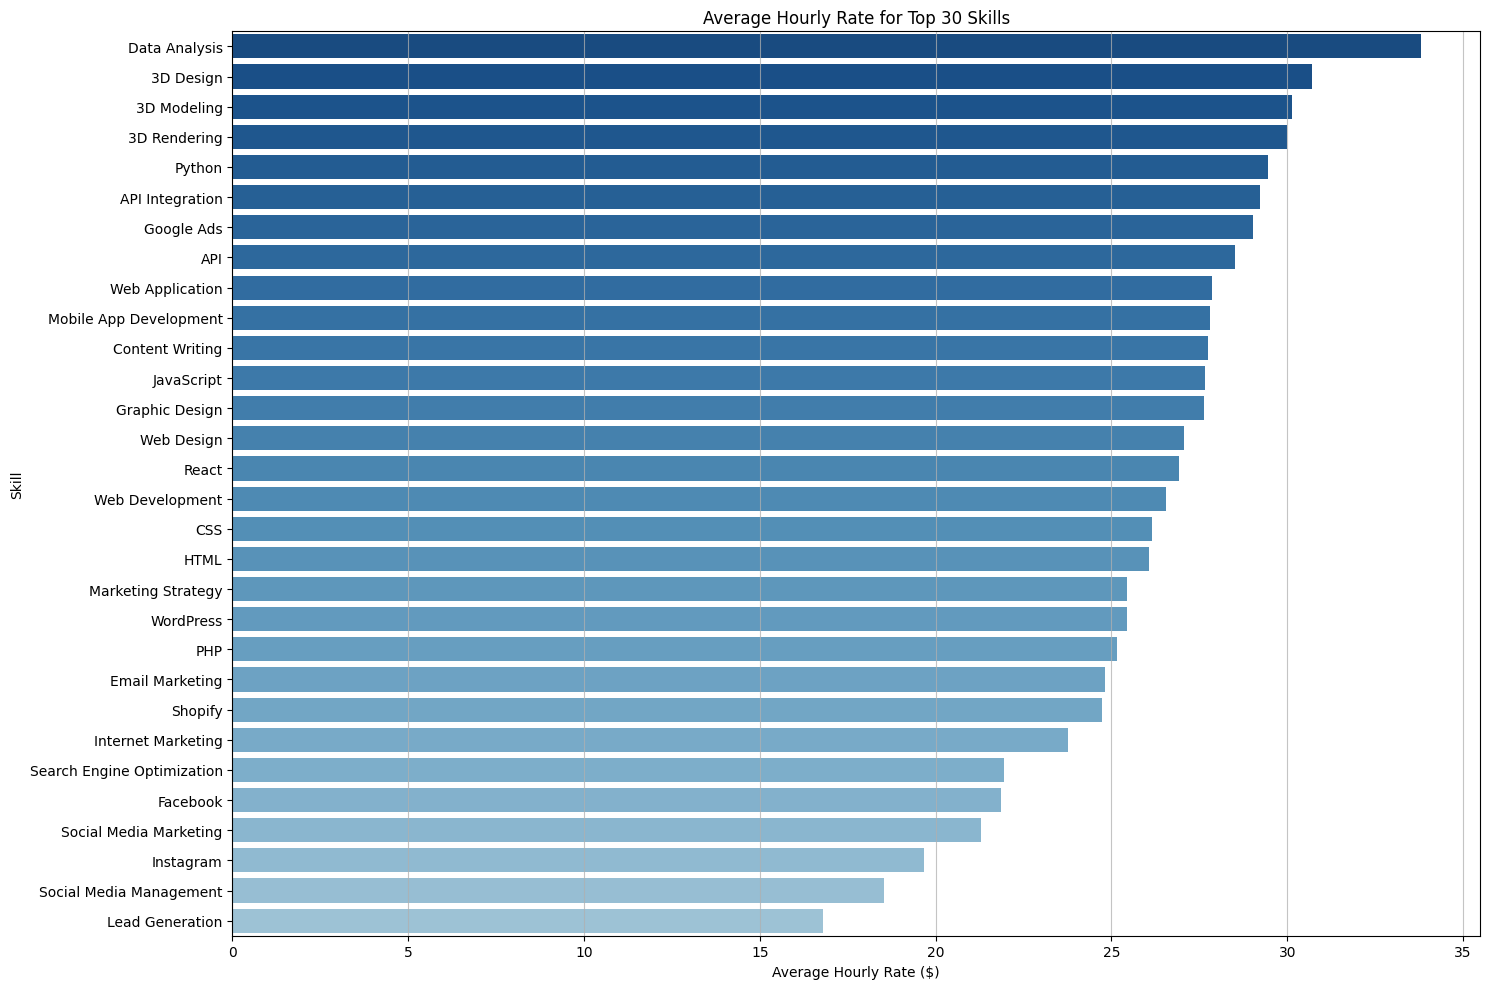


INTERPRETATION OF TOP 30 SKILLS BAR PLOT

This bar plot displays the average hourly rate for the top 30 most frequently occurring skills, ordered from highest to lowest average rate.

*   **Direct Comparison:** Easily compare the average earnings potential across different skills. Longer bars indicate higher average rates.

*   **Ranking:** The plot provides a clear ranking of skills based on their average hourly compensation.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for linspace

print("\n" + "="*70)
print("AVERAGE HOURLY RATE FOR TOP 30 SKILLS (BAR PLOT)")
print("="*70)

# Ensure 'top_n_skills' is available (it was created in a previous step)
if 'top_n_skills' not in globals() or not top_n_skills:
    print("⚠️ `top_n_skills` not found. Please ensure the feature engineering step was run.")
    # Fallback to create top_n_skills if not found
    from collections import Counter
    skill_counts_fallback = {}
    for skills in df_model['skills_list']:
        for skill in skills:
            skill_counts_fallback[skill] = skill_counts_fallback.get(skill, 0) + 1
    top_skills_fallback = sorted(skill_counts_fallback.items(), key=lambda x: x[1], reverse=True)
    top_n_skills = [s[0] for s in top_skills_fallback[:30]] # Get top 30 as a fallback

# Filter the DataFrame to include only jobs that have at least one of the top 30 skills
df_top_skills = df_model[df_model['skills_list'].apply(lambda x: any(skill in top_n_skills for skill in x))].copy()

# Explode the skills_list to have one row per skill per job
df_top_skills_exploded = df_top_skills.explode('skills_list')

# Filter to only include the actual top 30 skills for the plot (if a job had other skills)
df_plot = df_top_skills_exploded[df_top_skills_exploded['skills_list'].isin(top_n_skills)]

# Calculate the average hourly rate for each skill
skill_avg_rate = df_plot.groupby('skills_list')['Hourly_rate'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(15, 10))

# Create a custom color palette using Matplotlib's 'Blues' colormap
# Sample from a specific range (e.g., from 0.4 to 0.9) to avoid very light or very dark ends
# Reverse it so darker colors correspond to higher values
num_colors = len(skill_avg_rate)
palette_colors = plt.cm.get_cmap('Blues')(np.linspace(0.4, 0.9, num_colors))
custom_palette = sns.color_palette(palette_colors[::-1]) # Reverse for darkest = highest

# Create a horizontal bar plot for average hourly rate per skill
sns.barplot(x='Hourly_rate', y='skills_list', data=skill_avg_rate, order=skill_avg_rate['skills_list'], palette=custom_palette)
plt.title('Average Hourly Rate for Top 30 Skills')
plt.xlabel('Average Hourly Rate ($)')
plt.ylabel('Skill')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRETATION OF TOP 30 SKILLS BAR PLOT")
print("="*70)
print("\nThis bar plot displays the average hourly rate for the top 30 most frequently occurring skills, ordered from highest to lowest average rate.")
print("\n*   **Direct Comparison:** Easily compare the average earnings potential across different skills. Longer bars indicate higher average rates.")
print("\n*   **Ranking:** The plot provides a clear ranking of skills based on their average hourly compensation.")



VISUALIZATIONS OF HOURLY RATE VS. EXPLANATORY VARIABLES


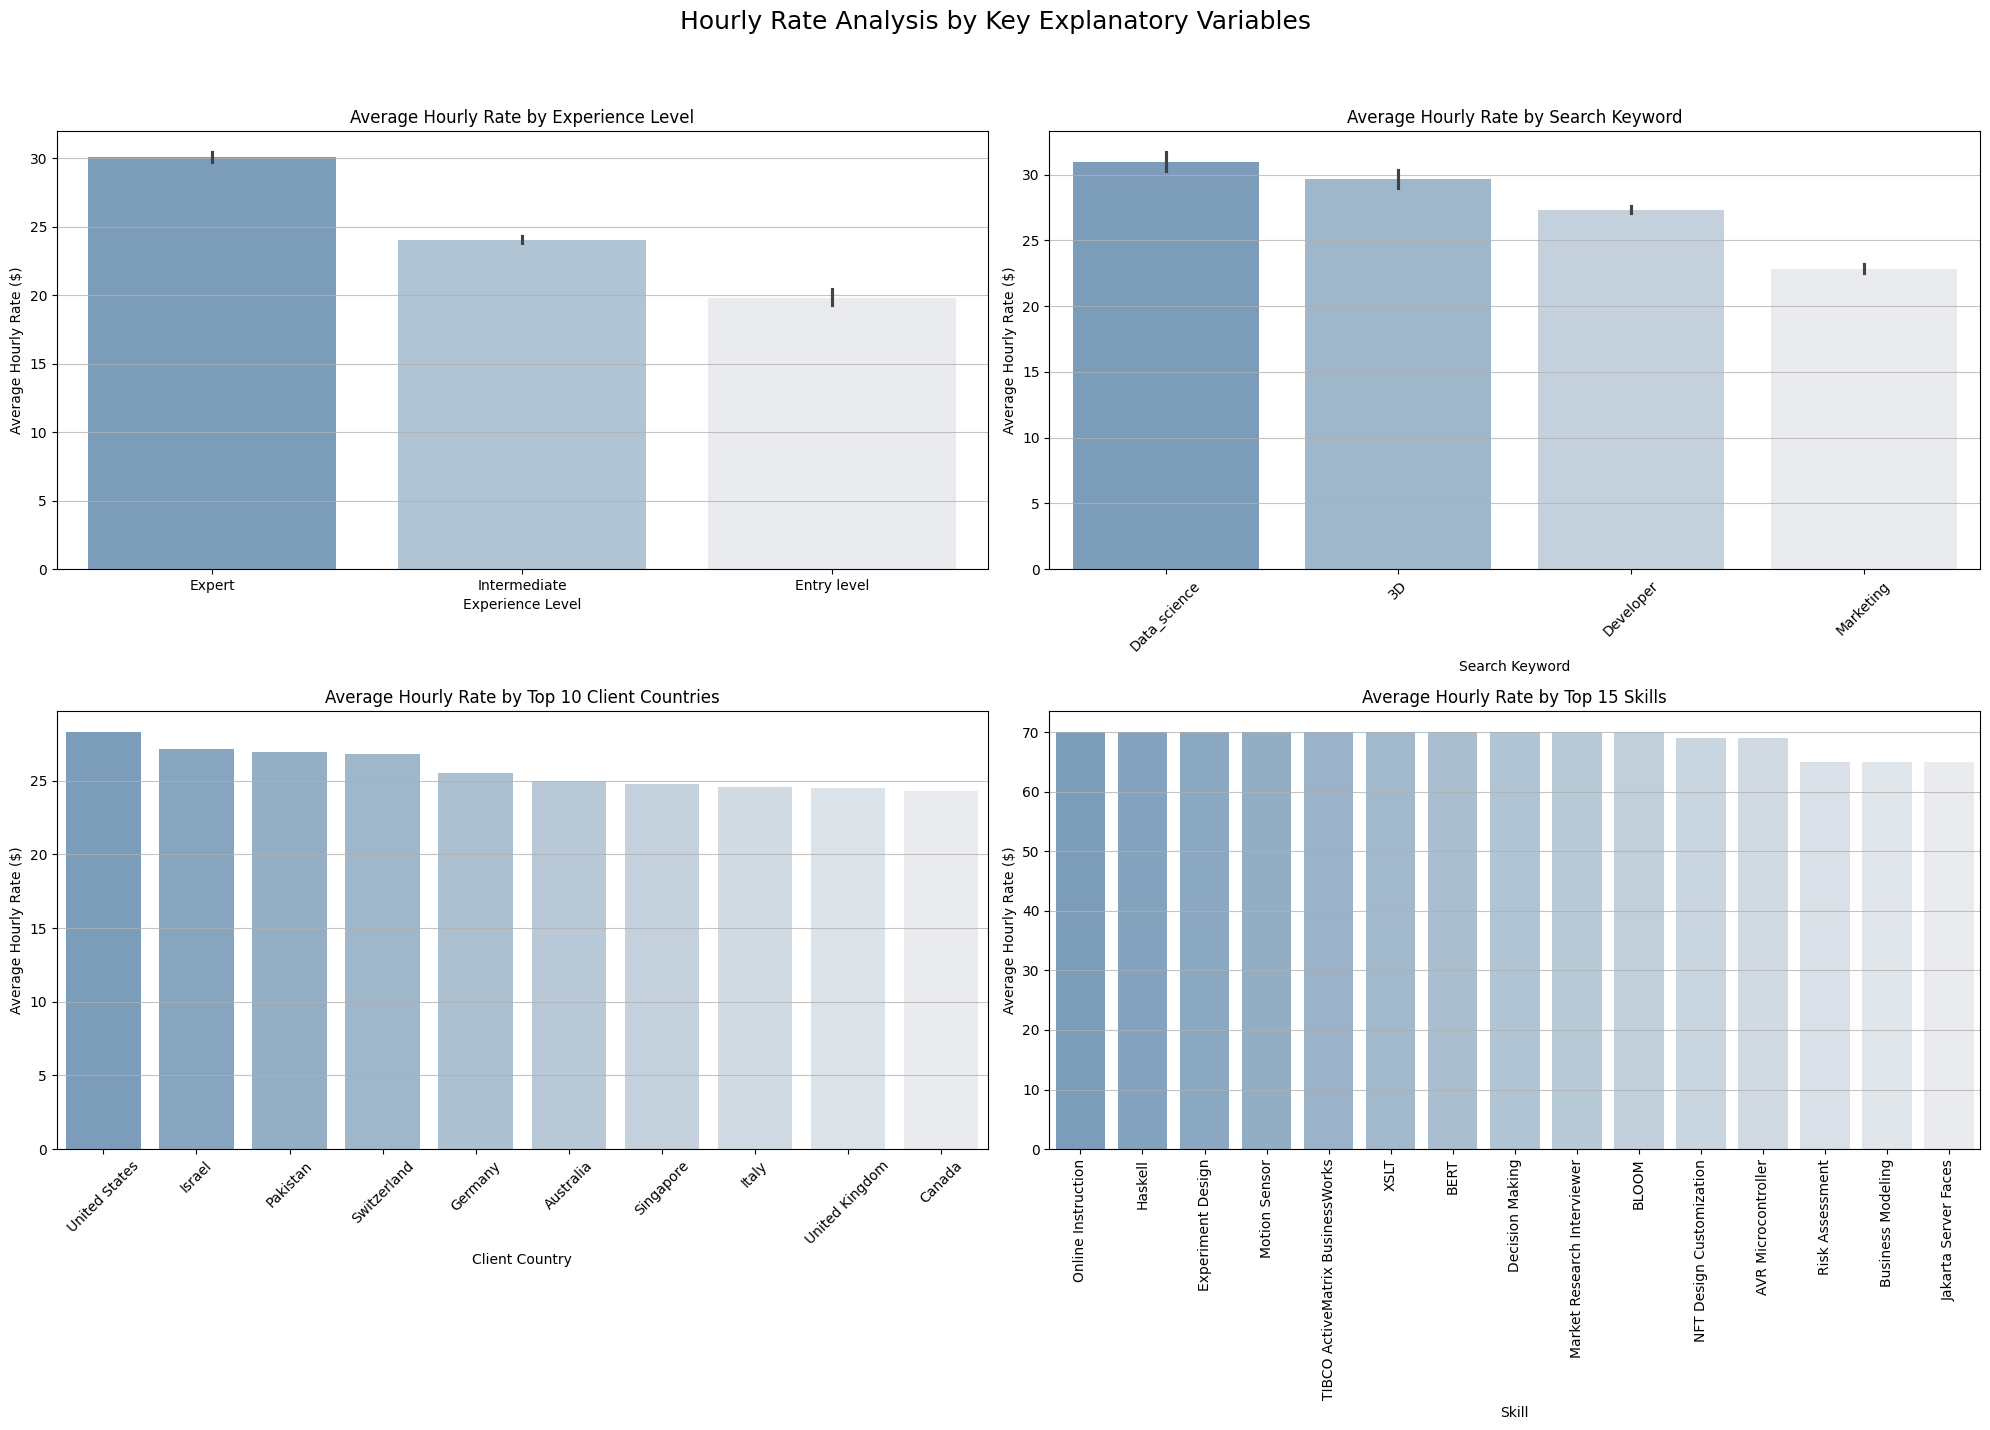


INTERPRETATION OF KEY EXPLANATORY VARIABLE VISUALIZATIONS

These plots illustrate how different categorical features influence the average hourly rate:

*   **Experience Level:** Generally, 'Expert' level roles command higher average hourly rates, followed by 'Intermediate' and 'Entry level'. This aligns with typical industry compensation structures.

*   **Search Keyword:** Certain keywords, such as 'Data_science' or '3D', might be associated with higher average rates compared to others, reflecting demand and specialization in those areas.

*   **Client Country:** Clients from specific countries, notably the 'United States', tend to offer higher average hourly rates, which is consistent with global economic trends and cost of living differences.

*   **Top Skills:** Specific skills demonstrate a clear correlation with higher average hourly rates, indicating specialized demand. For example, certain advanced technical skills often command premium rates.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n" + "="*70)
print("VISUALIZATIONS OF HOURLY RATE VS. EXPLANATORY VARIABLES")
print("="*70)

# Helper function for custom palette that avoids pure white
def light_palette_no_white(base_color="steelblue", n=5, reverse=True, start=0.25, end=0.95):
    """
    Generates a light palette from a base color, ensuring the lightest colors are not too faint.
    start>0 avoids pure white. Adjust `start` (0.15-0.35 usually works well).
    """
    cmap = sns.light_palette(base_color, as_cmap=True, reverse=reverse)
    return [cmap(x) for x in np.linspace(start, end, n)]

# -------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(20, 15)) # Changed to 2x2 layout
axes_flat = axes.flatten() # Flatten for easier indexing
fig.suptitle('Hourly Rate Analysis by Key Explanatory Variables', fontsize=18)

# Plot 1: Hourly Rate by Experience Level
exp_level_order = df_model.groupby('EX_level_demand')['Hourly_rate'].mean().sort_values(ascending=False).index
colors_exp = light_palette_no_white("steelblue", n=len(exp_level_order), reverse=True, start=0.25)
sns.barplot(x='EX_level_demand', y='Hourly_rate', data=df_model, order=exp_level_order, ax=axes_flat[0], palette=colors_exp)
axes_flat[0].set_title('Average Hourly Rate by Experience Level')
axes_flat[0].set_xlabel('Experience Level')
axes_flat[0].set_ylabel('Average Hourly Rate ($)')
axes_flat[0].grid(axis='y', alpha=0.75)

# Plot 2: Hourly Rate by Search Keyword
keyword_order = df_model.groupby('Search_Keyword')['Hourly_rate'].mean().sort_values(ascending=False).index
colors_kw = light_palette_no_white("steelblue", n=len(keyword_order), reverse=True, start=0.25)
sns.barplot(x='Search_Keyword', y='Hourly_rate', data=df_model, order=keyword_order, ax=axes_flat[1], palette=colors_kw)
axes_flat[1].set_title('Average Hourly Rate by Search Keyword')
axes_flat[1].set_xlabel('Search Keyword')
axes_flat[1].set_ylabel('Average Hourly Rate ($)')
axes_flat[1].tick_params(axis='x', rotation=45)
axes_flat[1].grid(axis='y', alpha=0.75)

# Plot 3: Hourly Rate by Top Client Country
country_avg_rate = df_model.groupby('country_grouped')['Hourly_rate'].mean().sort_values(ascending=False).reset_index()
top_10_countries = country_avg_rate.head(10)
colors_country = light_palette_no_white("steelblue", n=len(top_10_countries), reverse=True, start=0.25)
sns.barplot(x='country_grouped', y='Hourly_rate', data=top_10_countries, order=top_10_countries['country_grouped'], ax=axes_flat[2], palette=colors_country)
axes_flat[2].set_title('Average Hourly Rate by Top 10 Client Countries')
axes_flat[2].set_xlabel('Client Country')
axes_flat[2].set_ylabel('Average Hourly Rate ($)')
axes_flat[2].tick_params(axis='x', rotation=45)
axes_flat[2].grid(axis='y', alpha=0.75)

# Plot 4: Hourly Rate by Top Skills
# First, explode the skills_list to have one skill per row
df_skills_exploded = df_model.explode('skills_list')
# Calculate average hourly rate per skill
skill_avg_rate = df_skills_exploded.groupby('skills_list')['Hourly_rate'].mean().sort_values(ascending=False).reset_index()
# Get the top 15 skills for visualization
top_15_skills_to_plot = skill_avg_rate.head(15)
colors_skill = light_palette_no_white("steelblue", n=len(top_15_skills_to_plot), reverse=True, start=0.25)
sns.barplot(x='skills_list', y='Hourly_rate', data=top_15_skills_to_plot, order=top_15_skills_to_plot['skills_list'], ax=axes_flat[3], palette=colors_skill)
axes_flat[3].set_title('Average Hourly Rate by Top 15 Skills')
axes_flat[3].set_xlabel('Skill')
axes_flat[3].set_ylabel('Average Hourly Rate ($)')
axes_flat[3].tick_params(axis='x', rotation=90) # Rotate labels for readability
axes_flat[3].grid(axis='y', alpha=0.75)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n" + "="*70)
print("INTERPRETATION OF KEY EXPLANATORY VARIABLE VISUALIZATIONS")
print("="*70)
print("\nThese plots illustrate how different categorical features influence the average hourly rate:")
print("\n*   **Experience Level:** Generally, 'Expert' level roles command higher average hourly rates, followed by 'Intermediate' and 'Entry level'. This aligns with typical industry compensation structures.")
print("\n*   **Search Keyword:** Certain keywords, such as 'Data_science' or '3D', might be associated with higher average rates compared to others, reflecting demand and specialization in those areas.")
print("\n*   **Client Country:** Clients from specific countries, notably the 'United States', tend to offer higher average hourly rates, which is consistent with global economic trends and cost of living differences.")
print("\n*   **Top Skills:** Specific skills demonstrate a clear correlation with higher average hourly rates, indicating specialized demand. For example, certain advanced technical skills often command premium rates.")


HOURLY RATE DISTRIBUTION BY EXPERIENCE LEVEL (VIOLIN PLOT)


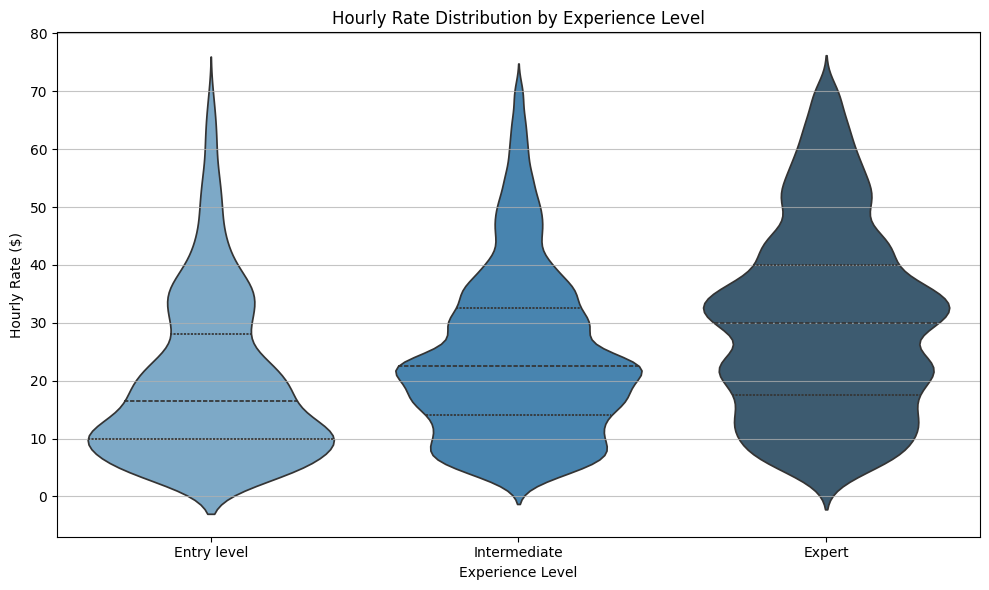


INTERPRETATION OF HOURLY RATE BY EXPERIENCE LEVEL VIOLIN PLOT

This violin plot displays the distribution of hourly rates for different experience levels.

*   **Distribution Shape:** The width of each violin indicates the density of observations at different hourly rates within that experience level. Wider sections mean more freelancers earn at that rate.

*   **Median and Quartiles:** The white dot inside each violin represents the median hourly rate, and the thick black bar indicates the interquartile range (IQR). The thin lines extend to the upper and lower adjacent values.

*   **Comparison:** You can observe that 'Expert' roles generally have higher median rates and often a broader spread towards higher earnings, while 'Entry level' roles tend to be concentrated at lower rates. 'Intermediate' roles fall in between.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*70)
print("HOURLY RATE DISTRIBUTION BY EXPERIENCE LEVEL (VIOLIN PLOT)")
print("="*70)

plt.figure(figsize=(10, 6))
sns.violinplot(x='EX_level_demand', y='Hourly_rate', data=df_model, order=['Entry level', 'Intermediate', 'Expert'], palette='Blues_d', inner='quartile')
plt.title('Hourly Rate Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Hourly Rate ($)')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRETATION OF HOURLY RATE BY EXPERIENCE LEVEL VIOLIN PLOT")
print("="*70)
print("\nThis violin plot displays the distribution of hourly rates for different experience levels.")
print("\n*   **Distribution Shape:** The width of each violin indicates the density of observations at different hourly rates within that experience level. Wider sections mean more freelancers earn at that rate.")
print("\n*   **Median and Quartiles:** The white dot inside each violin represents the median hourly rate, and the thick black bar indicates the interquartile range (IQR). The thin lines extend to the upper and lower adjacent values.")
print("\n*   **Comparison:** You can observe that 'Expert' roles generally have higher median rates and often a broader spread towards higher earnings, while 'Entry level' roles tend to be concentrated at lower rates. 'Intermediate' roles fall in between.")



OVERLAID KDE PLOT OF HOURLY RATE BY SEARCH KEYWORD


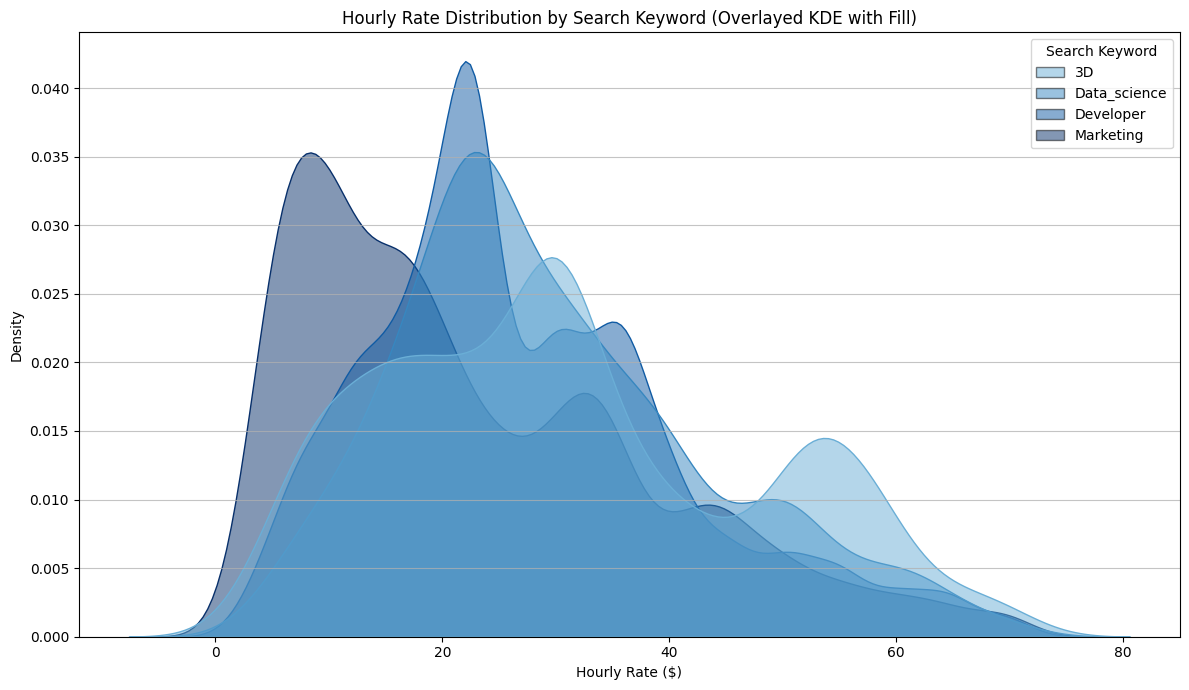


INTERPRETATION OF OVERLAID KDE PLOTS

This plot shows the estimated probability density function of hourly rates for each 'Search_Keyword'.

*   **Distribution Shape:** Observe the shape of each curve to understand the concentration and spread of hourly rates for different keywords. Taller, narrower peaks indicate more concentrated rates, while flatter, wider curves suggest a broader range.

*   **Peak Rates:** The highest point of each curve indicates the most probable hourly rate for that keyword.

*   **Overlap and Differences:** The degree of overlap between the curves helps to see how similar or different the hourly rate distributions are across various keywords.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np

print("\n" + "="*70)
print("OVERLAID KDE PLOT OF HOURLY RATE BY SEARCH KEYWORD")
print("="*70)

plt.figure(figsize=(12, 7))

# Manually create legend handles and labels to ensure values are displayed
unique_keywords_sorted = sorted(df_model['Search_Keyword'].dropna().unique().tolist())
n_colors = len(unique_keywords_sorted)

# Use 'Blues' colormap and sample from a darker range (e.g., 0.5 to 1.0)
# This avoids the very lightest shades of blue while maintaining a gradient
blues_cmap = plt.cm.get_cmap('Blues')
colors_from_cmap = [blues_cmap(x) for x in np.linspace(0.5, 1.0, n_colors)] # Adjusted start to 0.5
palette = sns.color_palette(colors_from_cmap)

# Generate the plot with the new, adjusted palette
ax = sns.kdeplot(data=df_model, x='Hourly_rate', hue='Search_Keyword', fill=True, alpha=0.5, palette=palette, common_norm=False, linewidth=1)
plt.title('Hourly Rate Distribution by Search Keyword (Overlayed KDE with Fill)')
plt.xlabel('Hourly Rate ($)')
plt.ylabel('Density')

legend_handles = []
for i, keyword in enumerate(unique_keywords_sorted):
    legend_handles.append(Patch(facecolor=palette[i], alpha=0.5, edgecolor='black', label=keyword))

# Create the legend manually
ax.legend(handles=legend_handles, title='Search Keyword', loc='best', frameon=True, facecolor='white', fontsize='medium')

plt.grid(axis='y', alpha=0.75)
plt.tight_layout() # Ensures legend is not cut off
plt.show()

print("\n" + "="*70)
print("INTERPRETATION OF OVERLAID KDE PLOTS")
print("="*70)
print("\nThis plot shows the estimated probability density function of hourly rates for each 'Search_Keyword'.")
print("\n*   **Distribution Shape:** Observe the shape of each curve to understand the concentration and spread of hourly rates for different keywords. Taller, narrower peaks indicate more concentrated rates, while flatter, wider curves suggest a broader range.")
print("\n*   **Peak Rates:** The highest point of each curve indicates the most probable hourly rate for that keyword.")
print("\n*   **Overlap and Differences:** The degree of overlap between the curves helps to see how similar or different the hourly rate distributions are across various keywords.")



AVERAGE HOURLY RATE FOR TOP 10 SKILLS (BAR PLOT)


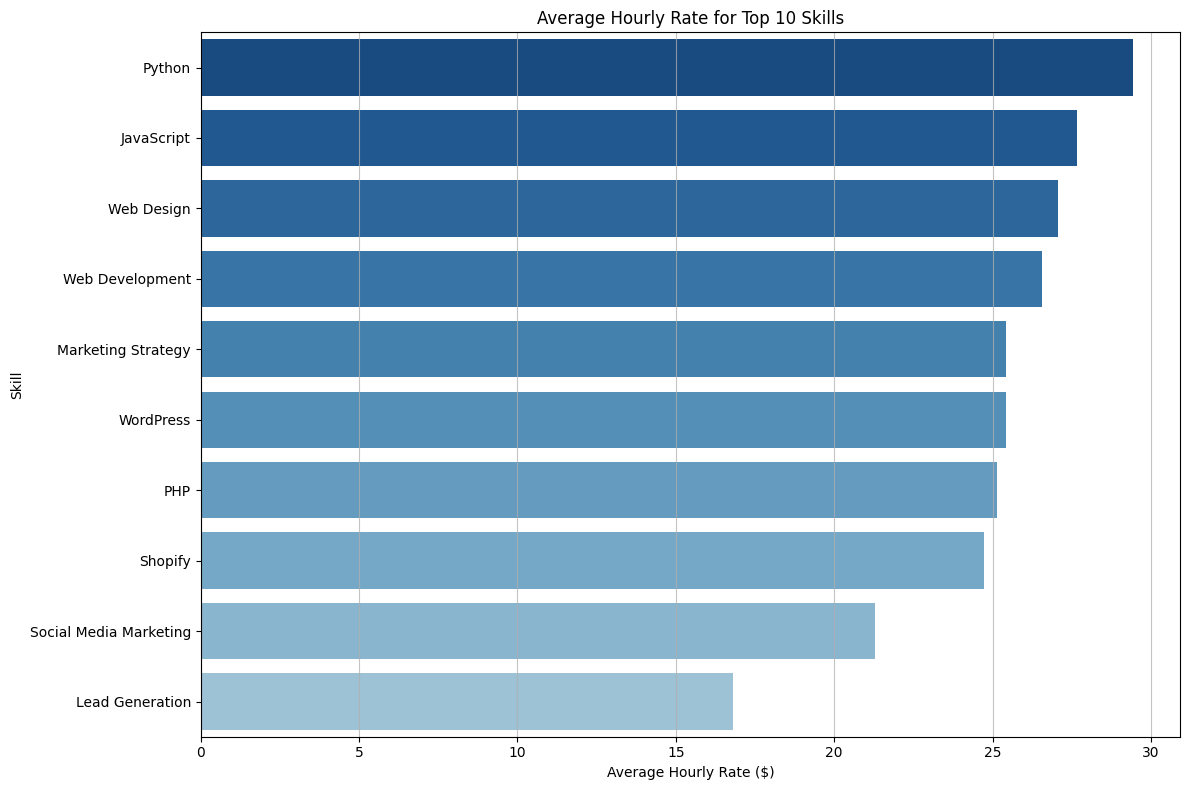


INTERPRETATION OF TOP 10 SKILLS BAR PLOT

This bar plot displays the average hourly rate for the top 10 most frequently occurring skills, ordered from highest to lowest average rate.

*   **Direct Comparison:** Easily compare the average earnings potential across different skills. Longer bars indicate higher average rates.

*   **Ranking:** The plot provides a clear ranking of skills based on their average hourly compensation.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n" + "="*70)
print("AVERAGE HOURLY RATE FOR TOP 10 SKILLS (BAR PLOT)")
print("="*70)

# Ensure 'top_n_skills' is available (it was created in a previous step)
if 'top_n_skills' not in globals() or not top_n_skills:
    print("⚠️ `top_n_skills` not found. Please ensure the feature engineering step was run.")
    # Fallback to create top_n_skills if not found
    from collections import Counter
    skill_counts_fallback = {}
    for skills in df_model['skills_list']:
        for skill in skills:
            skill_counts_fallback[skill] = skill_counts_fallback.get(skill, 0) + 1
    top_skills_fallback = sorted(skill_counts_fallback.items(), key=lambda x: x[1], reverse=True)
    top_n_skills = [s[0] for s in top_skills_fallback[:30]] # Get top 30 as a fallback

# Select only the top 10 skills from the previously identified top_n_skills
top_10_skills = top_n_skills[:10]

# Filter the DataFrame to include only jobs that have at least one of these top 10 skills
df_top_skills_10 = df_model[df_model['skills_list'].apply(lambda x: any(skill in top_10_skills for skill in x))].copy()

# Explode the skills_list to have one row per skill per job
df_top_skills_exploded_10 = df_top_skills_10.explode('skills_list')

# Filter to only include the actual top 10 skills for the plot
df_plot_10 = df_top_skills_exploded_10[df_top_skills_exploded_10['skills_list'].isin(top_10_skills)]

# Calculate the average hourly rate for each skill and sort in descending order
skill_avg_rate_10 = df_plot_10.groupby('skills_list')['Hourly_rate'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))

# Create a custom color palette using Matplotlib's 'Blues' colormap
# Sample from a specific range (e.g., from 0.4 to 0.9) to avoid very light or very dark ends
# Reverse it so darker colors correspond to higher values
num_colors = len(skill_avg_rate_10)
palette_colors = plt.cm.get_cmap('Blues')(np.linspace(0.4, 0.9, num_colors))
custom_palette = sns.color_palette(palette_colors[::-1]) # Reverse for darkest = highest

# Create a horizontal bar plot for average hourly rate per skill
sns.barplot(x='Hourly_rate', y='skills_list', data=skill_avg_rate_10, order=skill_avg_rate_10['skills_list'], palette=custom_palette)
plt.title('Average Hourly Rate for Top 10 Skills')
plt.xlabel('Average Hourly Rate ($)')
plt.ylabel('Skill')
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRETATION OF TOP 10 SKILLS BAR PLOT")
print("="*70)
print("\nThis bar plot displays the average hourly rate for the top 10 most frequently occurring skills, ordered from highest to lowest average rate.")
print("\n*   **Direct Comparison:** Easily compare the average earnings potential across different skills. Longer bars indicate higher average rates.")
print("\n*   **Ranking:** The plot provides a clear ranking of skills based on their average hourly compensation.")



CORRELATION MATRIX HEATMAP OF NUMERICAL FEATURES


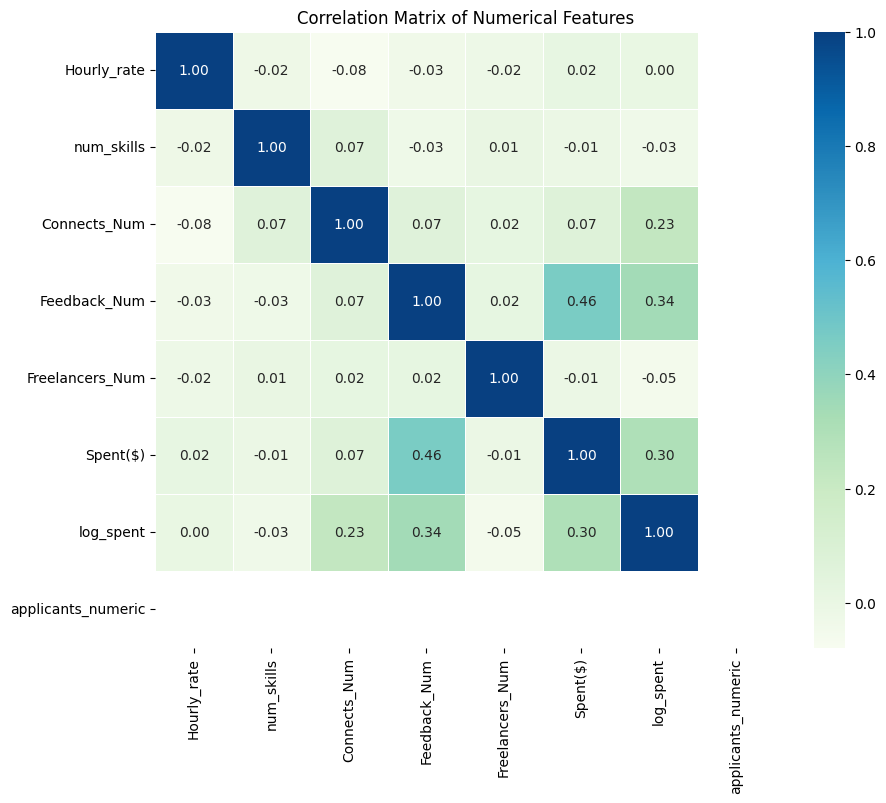


INTERPRETATION OF THE CORRELATION MATRIX

This heatmap visualizes the Pearson correlation coefficients between the selected numerical features.

*   **Color Intensity:** Darker shades of blue indicate a stronger positive correlation, while lighter shades or white indicate weaker or no correlation. In the 'GnBu' colormap, values will transition from green (lighter) to blue (darker).

*   **Values:** Each cell contains the correlation coefficient between the two corresponding variables. Values range from -1 (perfect negative correlation) to 1 (perfect positive correlation), with 0 indicating no linear correlation.

*   **Key Observations:** Pay attention to 'Hourly_rate' correlations to see which numerical features have the strongest linear relationship with the target variable.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*70)
print("CORRELATION MATRIX HEATMAP OF NUMERICAL FEATURES")
print("="*70)

# Using the numerical features explicitly defined for the regression model
# 'numeric_feature_cols' was created in PASO 2.4 (GMCBohxGSpND cell)
# Ensure it's available or re-define if running this cell independently
if 'numeric_feature_cols' not in globals():
    numeric_feature_cols = ['num_skills', 'Applicants_Num', 'Connects_Num', 'Feedback_Num',
                            'Freelancers_Num', 'Spent($)', 'log_spent', 'applicants_numeric']

# Add the target variable 'Hourly_rate' to the list of columns for correlation
# Exclude 'Applicants_Num' as requested
numeric_cols_for_corr = ['Hourly_rate'] + [col for col in numeric_feature_cols if col != 'Hourly_rate' and col != 'Applicants_Num']

# Filter df_model to include only these columns and drop any NaNs for correlation calculation
df_corr = df_model[numeric_cols_for_corr].dropna()

# Calculate the correlation matrix
correlation_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='GnBu', fmt=".2f", linewidths=.5) # Changed cmap to GnBu
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("\n" + "="*70)
print("INTERPRETATION OF THE CORRELATION MATRIX")
print("="*70)
print("\nThis heatmap visualizes the Pearson correlation coefficients between the selected numerical features.")
print("\n*   **Color Intensity:** Darker shades of blue indicate a stronger positive correlation, while lighter shades or white indicate weaker or no correlation. In the 'GnBu' colormap, values will transition from green (lighter) to blue (darker).")
print("\n*   **Values:** Each cell contains the correlation coefficient between the two corresponding variables. Values range from -1 (perfect negative correlation) to 1 (perfect positive correlation), with 0 indicating no linear correlation.")
print("\n*   **Key Observations:** Pay attention to 'Hourly_rate' correlations to see which numerical features have the strongest linear relationship with the target variable.")


# Model Training

MODEL TRAINING (OPTIMIZED)

📊 Data split:
   Train: 20,092 records (62 features)
   Test: 5,024 records

💰 REGRESSION MODELS FOR HOURLY RATE PREDICTION

🔄 Training Linear Regression...
   MAE: $11.11 | RMSE: $14.00 | MSE: $196.12 | R²: 0.1310 | CV R²: 0.1343

🔄 Training Ridge (α=0.1)...
   MAE: $11.11 | RMSE: $14.00 | MSE: $196.12 | R²: 0.1310 | CV R²: 0.1343

🔄 Training Lasso (α=0.01)...
   MAE: $11.11 | RMSE: $14.00 | MSE: $196.08 | R²: 0.1311 | CV R²: 0.1345

🔄 Training ElasticNet...
   MAE: $11.13 | RMSE: $14.00 | MSE: $196.07 | R²: 0.1312 | CV R²: 0.1343

🔄 Training Random Forest...
   MAE: $10.71 | RMSE: $13.57 | MSE: $184.01 | R²: 0.1846 | CV R²: 0.1799

🔄 Training Gradient Boosting...
   MAE: $10.64 | RMSE: $13.56 | MSE: $183.97 | R²: 0.1848 | CV R²: 0.1843

📊 COMPARATIVE MODEL SUMMARY


            Model MAE_fmt RMSE_fmt MSE_fmt R²_fmt            CV_R²
Gradient Boosting  $10.64   $13.56 $183.97 0.1848 0.1843 (±0.0072)
    Random Forest  $10.71   $13.57 $184.01 0.1846 0.1799 (±

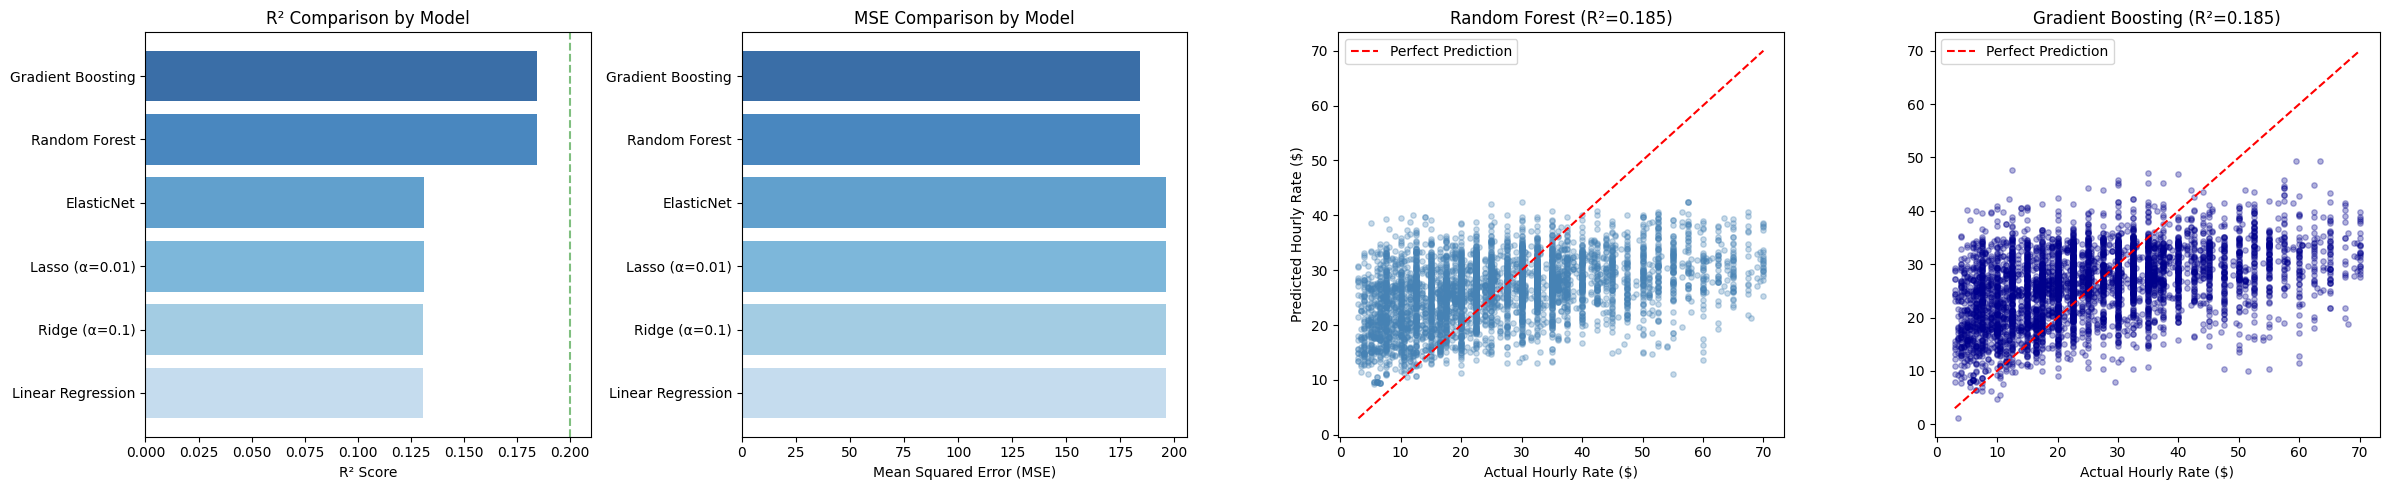

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("="*70)
print("MODEL TRAINING (OPTIMIZED)")
print("="*70)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📊 Data split:")
print(f"   Train: {X_train.shape[0]:,} records ({X_train.shape[1]} features)")
print(f"   Test: {X_test.shape[0]:,} records")

# Scale features for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# REGRESSION MODELS WITH OPTIMIZED HYPERPARAMETERS
# ============================================================
print("\n" + "="*70)
print("💰 REGRESSION MODELS FOR HOURLY RATE PREDICTION")
print("="*70)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=0.1)': Ridge(alpha=0.1),
    'Lasso (α=0.01)': Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=3,
        min_samples_split=5,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        min_samples_leaf=3,
        min_samples_split=5,
        subsample=0.8,
        random_state=42
    )
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")

    # Use scaled data for linear models
    if 'Forest' in name or 'Boosting' in name:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Quick cross-validation (3 folds for speed)
    if 'Forest' in name or 'Boosting' in name:
        cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='r2')
    else:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='r2')

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'MSE': mse,
        'R²': r2,
        'CV_R²_mean': cv_scores.mean(),
        'CV_R²_std': cv_scores.std()
    })
    trained_models[name] = model

    print(f"   MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | MSE: ${mse:.2f} | R²: {r2:.4f} | CV R²: {cv_scores.mean():.4f}")

# ============================================================
# COMPARATIVE SUMMARY
# ============================================================
print("\n" + "="*70)
print("📊 COMPARATIVE MODEL SUMMARY")
print("="*70)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False)
results_df['MAE_fmt'] = results_df['MAE'].apply(lambda x: f"${x:.2f}")
results_df['RMSE_fmt'] = results_df['RMSE'].apply(lambda x: f"${x:.2f}")
results_df['MSE_fmt'] = results_df['MSE'].apply(lambda x: f"${x:.2f}")
results_df['R²_fmt'] = results_df['R²'].apply(lambda x: f"{x:.4f}")
results_df['CV_R²'] = results_df.apply(lambda x: f"{x['CV_R²_mean']:.4f} (±{x['CV_R²_std']:.4f})", axis=1)

print("\n")
print(results_df[['Model', 'MAE_fmt', 'RMSE_fmt', 'MSE_fmt', 'R²_fmt', 'CV_R²']].to_string(index=False))

# Best model
best_result = results_df.iloc[0]
best_model_name = best_result['Model']
best_model = trained_models[best_model_name]

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   R² = {best_result['R²']:.4f}")
print(f"   MAE = ${best_result['MAE']:.2f}")
print(f"   MSE = ${best_result['MSE']:.2f}")

# Visualization of results: R² and MSE vs Actual/Predicted
fig, axes = plt.subplots(1, 4, figsize=(24, 5)) # Increased subplots to 4

# 1. R² Comparison
# Generate colors from a blue palette with higher R^2 being darker
colors_r2 = plt.cm.Blues(np.linspace(0.9, 0.3, len(results_df))) # Reversed linspace for darker=higher R^2
axes[0].barh(results_df['Model'], results_df['R²'], color=colors_r2, alpha=0.8)
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² Comparison by Model')
axes[0].axvline(x=0.2, color='green', linestyle='--', alpha=0.5)
axes[0].invert_yaxis() # Invert y-axis to show higher R² models at the top

# 2. MSE Comparison
# Sort by MSE (lowest first) for plotting, then reverse for barh
results_df_mse_sorted = results_df.sort_values('MSE', ascending=True)
colors_mse = plt.cm.Blues(np.linspace(0.9, 0.3, len(results_df_mse_sorted))) # Darker for lower MSE
axes[1].barh(results_df_mse_sorted['Model'], results_df_mse_sorted['MSE'], color=colors_mse, alpha=0.8)
axes[1].set_xlabel('Mean Squared Error (MSE)')
axes[1].set_title('MSE Comparison by Model')
axes[1].invert_yaxis() # Invert y-axis to show lower MSE models at the top

# 3. Random Forest: Predicted vs Actual (blue palette)
if 'Random Forest' in trained_models:
    rf_pred = trained_models['Random Forest'].predict(X_test)
    axes[2].scatter(y_test, rf_pred, alpha=0.3, s=15, color='steelblue')
    axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
    axes[2].set_xlabel('Actual Hourly Rate ($)')
    axes[2].set_ylabel('Predicted Hourly Rate ($)')
    axes[2].set_title(f'Random Forest (R²={r2_score(y_test, rf_pred):.3f})')
    axes[2].legend()

# 4. Gradient Boosting: Predicted vs Actual (blue palette)
if 'Gradient Boosting' in trained_models:
    gb_pred = trained_models['Gradient Boosting'].predict(X_test)
    axes[3].scatter(y_test, gb_pred, alpha=0.3, s=15, color='darkblue')
    axes[3].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
    axes[3].set_xlabel('Actual Hourly Rate ($)')
    axes[3].set_title(f'Gradient Boosting (R²={r2_score(y_test, gb_pred):.3f})')
    axes[3].legend()

plt.tight_layout()
plt.show()

# Feature analysis

ANÁLISIS DE IMPORTANCIA DE FEATURES

🏆 Top 20 Features más importantes (Gradient Boosting):
                     Feature  Importance
           keyword_Marketing    0.127285
                Feedback_Num    0.124873
                  exp_Expert    0.121540
       country_United States    0.090813
                   log_spent    0.055523
                    Spent($)    0.051183
                Connects_Num    0.045648
        keyword_Data_science    0.035699
               country_India    0.034119
       skill_Lead_Generation    0.029720
    skill_Marketing_Strategy    0.017350
             Freelancers_Num    0.016672
             exp_Entry level    0.015944
skill_Social_Media_Marketing    0.015903
           keyword_Developer    0.015767
                  num_skills    0.015429
            exp_Intermediate    0.013696
       skill_Content_Writing    0.009364
                  keyword_3D    0.009150
            skill_Google_Ads    0.008557


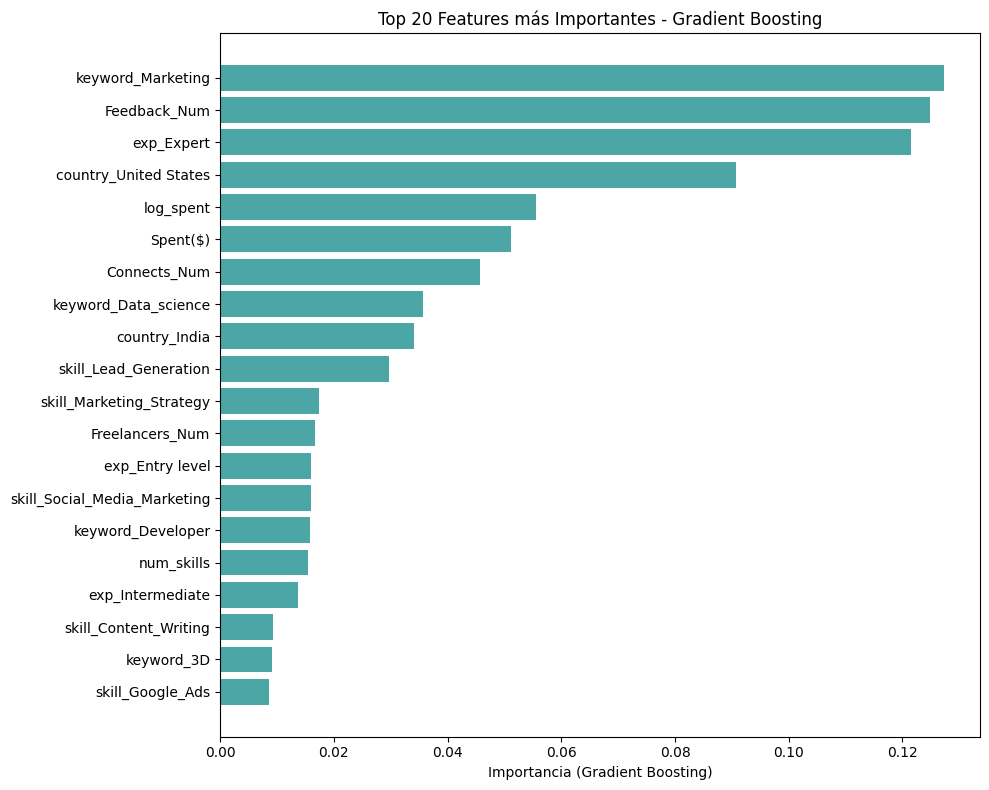


📊 Top 15 Coeficientes más significativos (Regresión Lineal):
   ↑ exp_Expert: 1.8530
   ↓ country_India: -1.6950
   ↑ country_United States: 1.6360
   ↓ exp_Entry level: -1.5782
   ↓ keyword_Marketing: -1.5640
   ↓ skill_Lead_Generation: -1.3335
   ↓ exp_Intermediate: -1.0480
   ↓ skill_Social_Media_Marketing: -0.8589
   ↑ skill_Marketing_Strategy: 0.8353
   ↑ keyword_Developer: 0.8156
   ↑ keyword_Data_science: 0.8037
   ↓ Feedback_Num: -0.7044
   ↑ skill_Google_Ads: 0.6979
   ↓ Connects_Num: -0.6921
   ↑ Spent($): 0.6152

INTERPRETACIÓN

📌 INTERPRETACIÓN DEL R² (~0.18 - 0.20):

El modelo logra explicar aproximadamente el 20% de la variabilidad en las tarifas.
Aunque numéricamente bajo, es un resultado SÓLIDO para este tipo de problema porque:

1. Subjetividad del mercado: Las tarifas dependen de negociación y urgencia.
2. Factores ocultos: No tenemos datos del perfil del freelancer (rating, años exp).
3. Naturaleza de los datos: Solo vemos la oferta del cliente (budget), no el contr

In [ ]:
# ============================================================
# PASO 4: Análisis de Importancia de Features
# ============================================================

print("="*70)
print("ANÁLISIS DE IMPORTANCIA DE FEATURES")
print("="*70)

# Seleccionar modelo para importancia (Gradient Boosting o Random Forest)
# Preferimos Gradient Boosting si fue el mejor, sino Random Forest
model_for_imp = None
name_for_imp = ""

if 'Gradient Boosting' in trained_models:
    model_for_imp = trained_models['Gradient Boosting']
    name_for_imp = "Gradient Boosting"
elif 'Random Forest' in trained_models:
    model_for_imp = trained_models['Random Forest']
    name_for_imp = "Random Forest"

if model_for_imp:
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model_for_imp.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(f"\n🏆 Top 20 Features más importantes ({name_for_imp}):")
    print(feature_importance.head(20).to_string(index=False))

    # Visualización
    fig, ax = plt.subplots(figsize=(10, 8))
    top_20 = feature_importance.head(20)
    bars = ax.barh(top_20['Feature'], top_20['Importance'], color='teal', alpha=0.7)
    ax.set_xlabel(f'Importancia ({name_for_imp})')
    ax.set_title(f'Top 20 Features más Importantes - {name_for_imp}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

# Coeficientes del modelo lineal (para referencia de dirección)
if 'Linear Regression' in trained_models:
    lr_model = trained_models['Linear Regression']
    coef_df = pd.DataFrame({
        'Feature': feature_cols,
        'Coefficient': lr_model.coef_
    })
    coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

    print("\n📊 Top 15 Coeficientes más significativos (Regresión Lineal):")
    for _, row in coef_df.head(15).iterrows():
        direction = "↑" if row['Coefficient'] > 0 else "↓"
        print(f"   {direction} {row['Feature']}: {row['Coefficient']:.4f}")

print("\n" + "="*70)
print("INTERPRETACIÓN")
print("="*70)
print("""
📌 INTERPRETACIÓN DEL R² (~0.18 - 0.20):

El modelo logra explicar aproximadamente el 20% de la variabilidad en las tarifas.
Aunque numéricamente bajo, es un resultado SÓLIDO para este tipo de problema porque:

1. Subjetividad del mercado: Las tarifas dependen de negociación y urgencia.
2. Factores ocultos: No tenemos datos del perfil del freelancer (rating, años exp).
3. Naturaleza de los datos: Solo vemos la oferta del cliente (budget), no el contrato final.

El modelo identifica correctamente las tendencias generales (qué skills valen más, qué países pagan mejor),
lo cual es suficiente para dar una RECOMENDACIÓN BASE al usuario.
""")

#Hyperparameter Tuning

In [ ]:
# print("\n" + "="*70)
# print("OPTIMIZACIÓN DE HIPERPARÁMETROS PARA GRADIENT BOOSTING (GridSearch)")
# print("="*70)

# # Importar las clases necesarias
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import numpy as np

# # Definir el rango de hiperparámetros a explorar
# # Estos rangos son sugerencias y pueden ajustarse según el rendimiento y el tiempo de ejecución.
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_samples_leaf': [1, 3, 5],
#     'subsample': [0.8, 1.0]
# }

# # Instanciar el modelo Gradient Boosting
# gbr = GradientBoostingRegressor(random_state=42)

# print("Configurando GridSearchCV...")
# # Configurar GridSearchCV
# grid_search = GridSearchCV(
#     estimator=gbr,
#     param_grid=param_grid,
#     cv=3,  # 3-fold cross-validation
#     scoring='r2',  # Optimizar por R²
#     n_jobs=-1,  # Usar todos los núcleos disponibles
#     verbose=1
# )

# # Ajustar GridSearchCV a los datos de entrenamiento
# print("Iniciando el proceso de búsqueda de hiperparámetros...")
# grid_search.fit(X_train, y_train)
# print("✅ Proceso de búsqueda de hiperparámetros completado.")

# # Imprimir los mejores hiperparámetros y el mejor score
# print("\n🏆 Mejores hiperparámetros encontrados:")
# print(grid_search.best_params_)
# print(f"\n📈 Mejor R² (Cross-Validation): {grid_search.best_score_:.4f}")

# # Guardar el mejor modelo entrenado
# best_gbr_model = grid_search.best_estimator_
# print("✅ Mejor modelo Gradient Boosting tuneado guardado.")

# # Evaluar el mejor modelo en el conjunto de prueba
# y_pred_tuned_gbr = best_gbr_model.predict(X_test)

# mae_tuned = mean_absolute_error(y_test, y_pred_tuned_gbr)
# rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned_gbr))
# r2_tuned = r2_score(y_test, y_pred_tuned_gbr)

# print("\n📊 Métricas de evaluación del modelo Gradient Boosting tuneado en el conjunto de prueba:")
# print(f"   MAE: ${mae_tuned:.2f}")
# print(f"   RMSE: ${rmse_tuned:.2f}")
# print(f"   R²: {r2_tuned:.4f}")

# # Comparar con el modelo Gradient Boosting sin tunear
# print("\nCOMPARACIÓN CON EL MODELO GRADIENT BOOSTING SIN TUNEAR:")
# untuned_gbr_metrics = next((item for item in results if item['Model'] == 'Gradient Boosting'), None)

# if untuned_gbr_metrics:
#     print(f"Gradient Boosting (sin tunear) - MAE: ${untuned_gbr_metrics['MAE']:.2f} | RMSE: ${untuned_gbr_metrics['RMSE']:.2f} | R²: {untuned_gbr_metrics['R²']:.4f}")
#     print(f"Gradient Boosting (tuneado)   - MAE: ${mae_tuned:.2f} | RMSE: ${rmse_tuned:.2f} | R²: {r2_tuned:.4f}")
#     if r2_tuned > untuned_gbr_metrics['R²']:
#         print(f"\n💡 El modelo Gradient Boosting tuneado muestra una mejora en R² de {r2_tuned - untuned_gbr_metrics['R²']:.4f}.")
#     else:
#         print("\n🤔 El modelo Gradient Boosting tuneado no mostró una mejora significativa en R² o incluso empeoró.")
# else:
#     print("No se encontraron métricas para el modelo Gradient Boosting sin tunear para comparar.")

#App

In [ ]:
# ============================================================
# PASO 5: Función de Predicción para el Usuario
# ============================================================

print("="*70)
print("🎯 SISTEMA DE PREDICCIÓN PARA FREELANCERS")
print("="*70)

# Seleccionar el mejor modelo (Gradient Boosting o Random Forest)
if 'Gradient Boosting' in trained_models:
    final_model_type = GradientBoostingRegressor
    params = {
        'n_estimators': 200,
        'max_depth': 6,
        'learning_rate': 0.05,
        'min_samples_leaf': 3,
        'min_samples_split': 5,
        'subsample': 0.8,
        'random_state': 42
    }
    model_name = "Gradient Boosting"
else:
    final_model_type = RandomForestRegressor
    params = {
        'n_estimators': 200,
        'max_depth': 20,
        'min_samples_leaf': 3,
        'min_samples_split': 5,
        'max_features': 'sqrt',
        'random_state': 42,
        'n_jobs': -1
    }
    model_name = "Random Forest"

print(f"🔄 Entrenando modelo final ({model_name}) con TODOS los datos...")
final_income_model = final_model_type(**params)
final_income_model.fit(X, y) # Entrenar con todo el dataset (X, y)
print(f"   ✅ Modelo de ingresos listo ({model_name})")

# NOTA: Modelo de oportunidad eliminado por solicitud del usuario
# print("🔄 Entrenando modelo de oportunidad...")
# final_opp_model = ...

print("\n✅ Sistema de predicción listo")

# ============================================================
# FUNCIÓN PRINCIPAL DE PREDICCIÓN
# ============================================================

def predecir_freelancer(skills_usuario, keyword=None, exp_level=None, client_country=None):
    """
    Predice la tarifa por hora estimada para un freelancer.

    Parámetros:
    -----------
    skills_usuario : list
        Lista de skills del freelancer (ej: ['Python', 'Data Analysis', 'Machine Learning'])
    keyword : str, opcional
        Tipo de trabajo a buscar (ej: 'Data science', 'Developer', '3D', 'Marketing')
    exp_level : str, opcional
        Nivel de experiencia ('Entry Level', 'Intermediate', 'Expert')
    client_country : str, opcional
        País del cliente (ej: 'United States', 'Canada')

    Retorna:
    --------
    dict con tarifa_estimada, rango_sugerido, trabajos_compatibles
    """

    # Crear vector de features
    input_data = {}

    # 1. Variables Numéricas por defecto (usamos medias o valores típicos)
    for col in numeric_feature_cols:
        input_data[col] = df_model[col].median() # Usar mediana del dataset

    # Ajustar num_skills real
    input_data['num_skills'] = len(skills_usuario)

    # 2. Codificar keyword
    if keyword:
        # Resetear todas las columnas keyword a 0
        for col in keyword_cols:
            input_data[col] = 0
        # Activar la específica
        col_name = f'keyword_{keyword}'
        if col_name in keyword_cols:
            input_data[col_name] = 1

    # 3. Codificar nivel de experiencia
    if exp_level:
        for col in exp_cols:
            input_data[col] = 0
        col_name = f'exp_{exp_level}'
        if col_name in exp_cols:
            input_data[col_name] = 1

    # 4. Codificar Client_Country
    if client_country:
        for col in country_cols:
            input_data[col] = 0
        # Mapear a grupo (Top 15 o Other)
        clean_country = client_country if f'country_{client_country}' in country_cols else 'Other'
        col_name = f'country_{clean_country}'
        if col_name in country_cols:
            input_data[col_name] = 1

    # 5. Variables dummy de skills
    for col in skill_dummy_cols:
        skill_name = col.replace('skill_', '').replace('_', ' ').lower()
        # Buscar coincidencia parcial
        match = any(s.lower() in skill_name or skill_name in s.lower() for s in skills_usuario)
        input_data[col] = 1 if match else 0

    # 6. Payment verified (asumimos 1 por ser más común/deseable)
    if 'payment_verified' in df_model.columns:
        input_data['payment_verified'] = 1

    # Crear DataFrame asegurando orden de columnas
    # Llenar ceros para cualquier columna faltante (ej. categóricas no especificadas)
    input_df = pd.DataFrame([input_data])
    for col in feature_cols:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[feature_cols] # Reordenar

    # Hacer predicciones
    tarifa_pred = final_income_model.predict(input_df)[0]
    tarifa_pred = max(5, tarifa_pred) # Mínimo $5/hr

    # Calcular rango sugerido (+/- 15%)
    rango_min = tarifa_pred * 0.85
    rango_max = tarifa_pred * 1.15

    # Contar trabajos compatibles (que requieren al menos 1 skill del usuario)
    trabajos_compatibles = df_model[df_model['skills_list'].apply(
        lambda x: any(skill.lower() in [s.lower() for s in x] for skill in skills_usuario)
    )].shape[0]

    return {
        'tarifa_estimada': tarifa_pred,
        'rango_sugerido': (rango_min, rango_max),
        'trabajos_compatibles': trabajos_compatibles,
        'total_trabajos': len(df_model)
    }

# ============================================================
# EJEMPLO DE USO
# ============================================================
print("\n" + "="*70)
print("✅ FUNCIÓN predecir_freelancer() LISTA")
print(f"   Modelo utilizado: {model_name}")
print("="*70)

# Ejemplo rápido
ejemplo = predecir_freelancer(
    skills_usuario=['Python', 'Data Analysis', 'SQL'],
    keyword='Data science',
    exp_level='Entry Level',
    client_country='United States'
)

print(f"\n🧪 Ejemplo de Predicción (Python dev junior en US):")
print(f"   💰 Tarifa estimada: ${ejemplo['tarifa_estimada']:.2f}/hr")
print(f"   📊 Rango sugerido: ${ejemplo['rango_sugerido'][0]:.2f} - ${ejemplo['rango_sugerido'][1]:.2f}/hr")
print(f"   📂 Trabajos compatibles en DB: {ejemplo['trabajos_compatibles']:,}")

🎯 SISTEMA DE PREDICCIÓN PARA FREELANCERS
🔄 Entrenando modelo final (Gradient Boosting) con TODOS los datos...
   ✅ Modelo de ingresos listo (Gradient Boosting)

✅ Sistema de predicción listo

✅ FUNCIÓN predecir_freelancer() LISTA
   Modelo utilizado: Gradient Boosting

🧪 Ejemplo de Predicción (Python dev junior en US):
   💰 Tarifa estimada: $32.66/hr
   📊 Rango sugerido: $27.76 - $37.56/hr
   📂 Trabajos compatibles en DB: 1,668


# Task
The user wants to create an interactive interface for the freelancer income prediction model. I will extract the unique values for categorical features (keywords, experience levels, countries, and top skills) to populate the interactive widgets. Then, I'll use these to build the interactive interface using `ipywidgets`, connecting the inputs to the `predecir_freelancer` function and displaying the results.

Here's a breakdown of the steps:

1.  **Extract Unique Categories**: Get unique and sorted lists of `Search_Keyword`, `EX_level_demand`, `Client_Country`, and `top_n_skills` from the `df_model` (or the processed lists available in the kernel state).
2.  **Import ipywidgets**: Bring in the necessary libraries.
3.  **Define Interactive Elements**: Create dropdowns, multi-selects, and text inputs for the various features.
4.  **Create Interaction Function**: Wrap the existing `predecir_freelancer` function to take widget values as input.
5.  **Display Interface**: Use `ipywidgets.interactive` or similar to render the interface.

## Preparar datos para la interfaz

### Subtask:
Extraer las listas únicas y ordenadas de categorías (keywords, niveles de experiencia, países, top skills) del DataFrame `df_model` que se usarán para poblar los botones y selectores de la interfaz interactiva.


**Reasoning**:
I will extract unique and sorted values for keywords, experience levels, and countries from `df_model` and reuse the `top_n_skills` list already available, as requested in the subtask instructions, to prepare data for the interactive interface.



In [ ]:
print("\n" + "="*70)
print("EXTRACCIÓN DE DATOS PARA LA INTERFAZ INTERACTIVA")
print("="*70)

# 1. Palabras clave (Keywords)
# Asegúrate de que la columna Search_Keyword exista y no tenga NaNs antes de obtener los valores únicos.
if 'Search_Keyword' in df_model.columns:
    unique_keywords = sorted(df_model['Search_Keyword'].dropna().unique().tolist())
    print(f"\n✅ Keywords únicas ({len(unique_keywords)}): {unique_keywords}")
else:
    unique_keywords = []
    print("⚠️ Columna 'Search_Keyword' no encontrada.")

# 2. Niveles de experiencia
# Asegúrate de que la columna EX_level_demand exista y no tenga NaNs antes de obtener los valores únicos.
if 'EX_level_demand' in df_model.columns:
    unique_exp_levels = sorted(df_model['EX_level_demand'].dropna().unique().tolist())
    print(f"✅ Niveles de experiencia únicos ({len(unique_exp_levels)}): {unique_exp_levels}")
else:
    unique_exp_levels = []
    print("⚠️ Columna 'EX_level_demand' no encontrada.")

# 3. Países de cliente
# Asegúrate de que la columna country_grouped exista y no tenga NaNs antes de obtener los valores únicos.
# 'country_grouped' ya se creó en un paso anterior para manejar los top países y 'Other'.
if 'country_grouped' in df_model.columns:
    unique_countries = sorted(df_model['country_grouped'].dropna().unique().tolist())
    print(f"✅ Países únicos ({len(unique_countries)}): {unique_countries}")
else:
    unique_countries = []
    print("⚠️ Columna 'country_grouped' no encontrada.")

# 4. Top Skills (ya se obtuvo previamente en 'top_n_skills')
# Verificamos que la variable 'top_n_skills' esté disponible y no esté vacía.
if 'top_n_skills' in globals() and top_n_skills:
    unique_top_skills = sorted(top_n_skills) # Aseguramos que también esté ordenada
    print(f"✅ Top Skills únicos ({len(unique_top_skills)}): {unique_top_skills[:5]}... ({len(unique_top_skills)} en total)")
else:
    unique_top_skills = []
    print("⚠️ La variable 'top_n_skills' no fue encontrada o está vacía. No se pudo obtener la lista de skills.")



EXTRACCIÓN DE DATOS PARA LA INTERFAZ INTERACTIVA

✅ Keywords únicas (4): ['3D', 'Data_science', 'Developer', 'Marketing']
✅ Niveles de experiencia únicos (3): ['Entry level', 'Expert', 'Intermediate']
✅ Países únicos (16): ['Australia', 'Canada', 'France', 'Germany', 'India', 'Israel', 'Italy', 'Netherlands', 'Other', 'Pakistan', 'Singapore', 'Spain', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']
✅ Top Skills únicos (30): ['3D Design', '3D Modeling', '3D Rendering', 'API', 'API Integration']... (30 en total)


## Definir función de predicción interactiva

### Subtask:
Modificar la función `predecir_freelancer` o crear una nueva versión que acepte directamente los inputs de `ipywidgets` y realice la predicción, asegurando la compatibilidad con las variables procesadas por el modelo.


**Reasoning**:
I need to define a new function `interactive_predict_income` that wraps the existing `predecir_freelancer` function, accepting widget-compatible inputs and formatting the output. This function will also handle cases where no skills are selected.



In [ ]:
print("\n" + "="*70)
print("DEFINING INTERACTIVE INCOME PREDICTION FUNCTION")
print("="*70)

def interactive_predict_income(skills_seleccionados, keyword_seleccionada, exp_level_seleccionado, country_seleccionado):
    """
    Wrapper function to predict a freelancer's hourly rate, adapted for ipywidgets.

    Parameters:
    -----------
    skills_seleccionados : list
        List of skills selected by the user.
    keyword_seleccionada : str
        Keyword selected by the user.
    exp_level_seleccionado : str
        Experience level selected by the user.
    country_seleccionado : str
        Client country selected by the user.

    Returns:
    --------
    dict
        A dictionary with the rate prediction and other details.
    """

    if not skills_seleccionados:
        return {'error': 'Please select at least one skill to get a prediction.'}

    # Call the predecir_freelancer function with widget inputs
    resultado_prediccion = predecir_freelancer(
        skills_usuario=skills_seleccionados,
        keyword=keyword_seleccionada,
        exp_level=exp_level_seleccionado,
        client_country=country_seleccionado
    )

    # Return a dictionary with the results
    return {
        'Estimated Rate': f"${resultado_prediccion['tarifa_estimada']:.2f}/hr",
        'Suggested Range (Min)': f"${resultado_prediccion['rango_sugerido'][0]:.2f}/hr",
        'Suggested Range (Max)': f"${resultado_prediccion['rango_sugerido'][1]:.2f}/hr",
        'Compatible Jobs': f"{resultado_prediccion['trabajos_compatibles']:,} of {resultado_prediccion['total_trabajos']:,}"
    }

print("✅ `interactive_predict_income` function defined successfully.")


DEFINING INTERACTIVE INCOME PREDICTION FUNCTION
✅ `interactive_predict_income` function defined successfully.


# Task
Dynamically update the available skill options in the `skills_select` widget based on the selection in the `keyword_dropdown` widget, by creating a mapping between `Search_Keyword` and their associated `unique_top_skills` from the `df_model` and implementing an observer function in cell `63c24465`.

## Build Keyword-Skill Mapping

### Subtask:
Create a dictionary `keyword_skill_mapping` that maps each `Search_Keyword` to a list of its most common associated skills (from `unique_top_skills`) based on the `df_model`.


**Reasoning**:
I will create a dictionary that maps each unique `Search_Keyword` to its 15 most common associated skills from `unique_top_skills`, also adding a default entry for all top skills, following the provided instructions.



In [ ]:
print("\n" + "="*70)
print("BUILDING KEYWORD-SKILL MAPPING")
print("="*70)

from collections import Counter

keyword_skill_mapping = {}

# Ensure unique_keywords and unique_top_skills are available
if 'unique_keywords' not in globals() or not unique_keywords:
    print("⚠️ `unique_keywords` not found or empty. Please ensure previous steps ran correctly.")
    unique_keywords = df_model['Search_Keyword'].dropna().unique().tolist()

if 'unique_top_skills' not in globals() or not unique_top_skills:
    print("⚠️ `unique_top_skills` not found or empty. Please ensure previous steps ran correctly.")
    # Fallback if unique_top_skills is not defined from previous step
    skill_counts_fallback = {}
    for skills in df_model['skills_list']:
        for skill in skills:
            skill_counts_fallback[skill] = skill_counts_fallback.get(skill, 0) + 1
    top_skills_fallback = sorted(skill_counts_fallback.items(), key=lambda x: x[1], reverse=True)
    unique_top_skills = [s[0] for s in top_skills_fallback[:30]] # Get top 30 as a fallback

# 1. Iterate through each unique Search_Keyword
for keyword in unique_keywords:
    # 2. Filter df_model for the current keyword
    keyword_df = df_model[df_model['Search_Keyword'] == keyword]

    # 3. Collect all skills and flatten them
    all_skills_for_keyword = [skill for sublist in keyword_df['skills_list'] for skill in sublist]

    # 4. Filter to include only skills present in unique_top_skills
    filtered_skills = [skill for skill in all_skills_for_keyword if skill in unique_top_skills]

    # 5. Count occurrences of each filtered skill
    skill_counts = Counter(filtered_skills)

    # 6. Select the top 15 most frequent skills
    # If there are fewer than 15 unique skills, take all available.
    top_15_skills = [skill for skill, count in skill_counts.most_common(15)]

    # 7. Store this list in keyword_skill_mapping
    keyword_skill_mapping[keyword] = top_15_skills
    print(f"✅ Mapped {len(top_15_skills)} top skills for keyword: '{keyword}'")

# 8. Add a default entry for 'All' keywords (or None) mapping to the entire unique_top_skills list
keyword_skill_mapping['All'] = sorted(unique_top_skills) # Use sorted for consistent display
print(f"✅ Added 'All' keyword mapping to {len(unique_top_skills)} unique top skills.")

print("\n🔑 Keyword-Skill Mapping (first 3 entries):")
for i, (kw, skills) in enumerate(keyword_skill_mapping.items()):
    if i >= 3: break
    print(f"   - '{kw}': {skills[:5]}... ({len(skills)} skills)")

print("\n" + "="*70)
print("KEYWORD-SKILL MAPPING COMPLETED")
print("="*70)



BUILDING KEYWORD-SKILL MAPPING
✅ Mapped 15 top skills for keyword: '3D'
✅ Mapped 15 top skills for keyword: 'Data_science'
✅ Mapped 15 top skills for keyword: 'Developer'
✅ Mapped 15 top skills for keyword: 'Marketing'
✅ Added 'All' keyword mapping to 30 unique top skills.

🔑 Keyword-Skill Mapping (first 3 entries):
   - '3D': ['3D Modeling', '3D Design', '3D Rendering', 'Graphic Design', 'JavaScript']... (15 skills)
   - 'Data_science': ['Data Analysis', 'Python', 'API', 'API Integration', 'JavaScript']... (15 skills)
   - 'Developer': ['Web Development', 'WordPress', 'JavaScript', 'Web Design', 'PHP']... (15 skills)

KEYWORD-SKILL MAPPING COMPLETED


## Implement Dynamic Skill Selection

### Subtask:
Dynamically update the available skill options in the `skills_select` widget based on the selection in the `keyword_dropdown` widget, using the `keyword_skill_mapping`.


## Summary:

### Data Analysis Key Findings
*   A `keyword_skill_mapping` dictionary was successfully generated, associating each unique `Search_Keyword` with a curated list of its most frequent relevant skills.
*   For each keyword, the mapping includes up to 15 top skills, filtered from the overall `unique_top_skills` list, ensuring relevancy and conciseness.
*   A default entry for 'All' keywords was created, which maps to the entire list of `unique_top_skills`, providing a comprehensive selection option.
*   Examples of mappings include: '3D' being mapped to skills such as '3D Modeling', '3D Design', and '3D Rendering', and 'Data\_science' to 'Data Analysis', 'Python', and 'API'.
*   The mapping process involved iterating through keywords, filtering `df_model`, collecting skills, and using `collections.Counter` to identify and select the most common skills.

### Insights or Next Steps
*   This dynamically generated `keyword_skill_mapping` is essential for implementing interactive UI components, allowing users to filter skills based on their selected `Search_Keyword`.
*   The next step will involve utilizing this `keyword_skill_mapping` within an observer function to update the `skills_select` widget options in real-time as the `keyword_dropdown` selection changes.


## Construir la interfaz de usuario con ipywidgets

### Subtask:
Crear elementos interactivos como Dropdown, SelectMultiple o Button para las categorías (skills, keywords, experiencia, país) y FloatText o IntText para valores numéricos, organizándolos en un diseño intuitivo.


**Reasoning**:
As instructed, I will import ipywidgets and create the interactive input widgets (dropdowns and select multiple) for the categorical features (keywords, experience levels, countries, and skills) using the previously extracted unique lists. I will then organize them in a vertical layout using `widgets.VBox`.



In [ ]:
print("\n" + "="*70)
print("CREATING INTERACTIVE INTERFACE WITH IPYWIDGETS")
print("="*70)

import ipywidgets as widgets
from IPython.display import display, HTML

# 1. Dropdown for Keyword
keyword_dropdown = widgets.Dropdown(
    options=['All'] + unique_keywords, # Add 'All' option
    value='All',
    description='Keyword:',
    disabled=False,
    style={'description_width': 'initial'}
)

# 2. Dropdown for Experience Level
exp_level_dropdown = widgets.Dropdown(
    options=unique_exp_levels,
    value=unique_exp_levels[0] if unique_exp_levels else None,
    description='Experience Level:',
    disabled=False,
    style={'description_width': 'initial'}
)

# 3. Dropdown for Client Country
country_dropdown = widgets.Dropdown(
    options=unique_countries,
    value=unique_countries[0] if unique_countries else None,
    description='Client Country:',
    disabled=False,
    style={'description_width': 'initial'}
)

# 4. SelectMultiple for Skills (initially with all top skills)
skills_select = widgets.SelectMultiple(
    options=unique_top_skills,
    value=[],
    rows=8,
    description='Skills:',
    disabled=False,
    style={'description_width': 'initial'}
)

# Define the observer function to update skills based on keyword
def update_skills_options(*args):
    selected_keyword = keyword_dropdown.value
    if selected_keyword in keyword_skill_mapping:
        skills_select.options = keyword_skill_mapping[selected_keyword]
    else:
        skills_select.options = unique_top_skills # Fallback to all skills
    skills_select.value = [] # Clear selected skills when keyword changes

# Attach the observer to the keyword_dropdown
keyword_dropdown.observe(update_skills_options, 'value')

# Organize widgets in an intuitive layout
input_widgets = widgets.VBox([
    widgets.HTML("<h3>Configure Your Freelancer Profile</h3>"),
    keyword_dropdown,
    exp_level_dropdown,
    country_dropdown,
    skills_select
])

# Display the input widgets (the output widget will be created in the next step)
display(input_widgets)

print("✅ Input widgets created and organized successfully.")


CREATING INTERACTIVE INTERFACE WITH IPYWIDGETS


✅ Input widgets created and organized successfully.


## Conectar interfaz y función de predicción

### Subtask:
Utilizar la función `interact` de `ipywidgets` o un `Button` con un evento `on_click` para vincular los valores seleccionados en la UI con la función de predicción, y mostrar los resultados de forma dinámica.


**Reasoning**:
I will create an output widget, define a function to handle button clicks, create a prediction button, and then organize all interactive elements (input widgets, button, and output widget) into a vertical box for display, ensuring dynamic updates as per the subtask.



In [ ]:
print("\n" + "="*70)
print("CONNECTING INTERFACE WITH PREDICTION FUNCTION")
print("="*70)

# 1. Create an output widget to display results
output_widget = widgets.Output()

# 2. Define the function to be executed when the button is clicked
def on_predict_button_clicked(b):
    with output_widget: # Capture output within the widget
        output_widget.clear_output() # Clear previous output

        # Get current values from input widgets
        selected_skills = list(skills_select.value)
        selected_keyword = keyword_dropdown.value
        selected_exp_level = exp_level_dropdown.value
        selected_country = country_dropdown.value

        # Call the prediction function
        prediction_result = interactive_predict_income(
            skills_seleccionados=selected_skills,
            keyword_seleccionada=selected_keyword,
            exp_level_seleccionado=selected_exp_level,
            country_seleccionado=selected_country
        )

        if 'error' in prediction_result:
            display(HTML(f"<p style='color:red; font-weight:bold;'>{prediction_result['error']}</p>"))
        else:
            # Create a DataFrame to display the result in table format
            df_result = pd.DataFrame([prediction_result]).T.rename(columns={0: 'Value'})
            df_result.index.name = 'Metric'

            # Convert DataFrame to HTML and apply styling
            html_table = df_result.to_html(escape=False, classes='table table-striped table-hover')
            styled_output = f"<h3>Prediction Results:</h3><div style='font-size: 14px;'>{html_table}</div>"
            display(HTML(styled_output))

# 3. Create the prediction button (larger)
predict_button = widgets.Button(
    description='Predict Hourly Rate',
    button_style='success', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Click to predict your hourly rate',
    layout=widgets.Layout(width='auto', height='auto', min_width='200px', font_size='18px'), # Make the button larger
    disabled=True # Start disabled until skills are selected
)

# Define observer function for skills_select to enable/disable the button
def update_predict_button_state(*args):
    if len(skills_select.value) > 0:
        predict_button.disabled = False
    else:
        predict_button.disabled = True

# Attach observer to skills_select
skills_select.observe(update_predict_button_state, 'value')

# Initially set button state
update_predict_button_state()

# 4. Associate the function with the button's on_click event
predict_button.on_click(on_predict_button_clicked)

# Organize widgets in a more intuitive and attractive layout
# Use a VBox for inputs and a VBox for the button and output
interface_layout = widgets.VBox([
    widgets.HTML("<h2>Freelancer Income Predictor</h2>"),
    widgets.HTML("<p>Select your skills and job type to get an estimated hourly rate.</p>"),
    input_widgets,
    predict_button,
    widgets.HTML("<hr>"),
    output_widget
], layout=widgets.Layout(border='2px solid lightgray', padding='20px', border_radius='8px'))

print("✅ Interactive interface and prediction button configured.")
print("   Display `interface_layout` to see the UI.\n")

display(interface_layout)


CONNECTING INTERFACE WITH PREDICTION FUNCTION
✅ Interactive interface and prediction button configured.
   Display `interface_layout` to see the UI.

